In [1]:
import sys
from pathlib import Path

repo_parent = str(Path("/Users/yaniszaim").resolve())
if repo_parent not in sys.path:
    sys.path.insert(0, repo_parent)

print(sys.path[0])

/Users/yaniszaim


In [2]:
import deephedging
print(deephedging.__file__)

/Users/yaniszaim/deephedging/__init__.py


In [3]:
import sys
print(sys.executable)

/opt/anaconda3/envs/dh/bin/python


# BLACK SCHOLES WORLD

## Vanilla DH BS - No initial Delta, No Recurrence

In [4]:
print("Deep Hedging AI says hello (Torch) ... ", end='')
from IPython.display import display, Markdown
from deephedging.run_train_torch import run_experiment


display(Markdown("## Deep Hedging in a Black-Scholes World"))

results_bs = run_experiment(
    override_world={
        "samples": 10000,
        "steps": 20,
        "black_scholes": True,
    },
    override_objective={
        "risk_measure": "cvar",
        "risk_aversion": 1.0,
    },
    override_model={
        "agent_type": "feed_forward",
        "feature_list": ["price", "delta", "time_left"],
        "network_depth": 3,
        "network_width": 20,
        "activation": "softplus",
    },
    override_training={
        "lr": 1e-3,
        "batch_size": None,
        "epochs": 800,
        "epoch_refresh": 5,
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": 0.5,
        "lr_decay_patience": 25,
        "lr_min": 1e-5,
        "scheduler_monitor": "val",
    },
)

config = results_bs["config"]
world = results_bs["world"]
val_world = results_bs["val_world"]
gym_vanilla = results_bs["gym"]
vanilla_bs_gym = gym_vanilla
r = results_bs["training_result"]

print("Keys of the dictionary returned by the gym: ", r.keys())
print("=========================================")
print("Torch config")
print("=========================================")
print(config)


Deep Hedging AI says hello (Torch) ... 

## Deep Hedging in a Black-Scholes World


PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.1969 | train 0.1887 | val 0.1801
epoch 5 | batch 0.1789 | train 0.1779 | val 0.1709
epoch 10 | batch 0.1677 | train 0.1674 | val 0.1617
epoch 15 | batch 0.1658 | train 0.1648 | val 0.1595
epoch 20 | batch 0.1654 | train 0.1648 | val 0.1597
epoch 25 | batch 0.1655 | train 0.1648 | val 0.1595
epoch 30 | batch 0.1656 | train 0.1652 | val 0.1601
epoch 35 | batch 0.1656 | train 0.1648 | val 0.1597
epoch 40 | batch 0.1654 | train 0.1650 | val 0.1595
epoch 45 | batch 0.1652 | train 0.1647 | val 0.1595
epoch 50 | batch 0.1650 | train 0.1656 | val 0.1606
epoch 55 | batch 0.1651 | train 0.1649 | val 0.1598
epoch 60 | batch 0.1651 | train 0.1649 | val 0.1596
epoch 65 | batch 0.1651 | train 0.1647 | val 0.1595
epoch 70 | batch 0.1650 | train 0.1647 | val 0.1594
epoch 75 | batch 0.1650 | train 0.1649 | val 0.1596
epoch 80 | batch 0.1650 | train 0.1649 | val 0.1597
epoch 85 | batch 0.1650 | train 0.1647 | val 0.1595
epoch 90 | bat

## Prototype-Based Black Scholes


PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs


/opt/anaconda3/envs/dh/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


epoch 0 | batch 0.1829 | train 0.1763 | val 0.1686
epoch 5 | batch 0.1662 | train 0.1654 | val 0.1595
epoch 10 | batch 0.1626 | train 0.1623 | val 0.1561
epoch 15 | batch 0.1612 | train 0.1609 | val 0.1554
epoch 20 | batch 0.1608 | train 0.1608 | val 0.1556
epoch 25 | batch 0.1605 | train 0.1603 | val 0.1552
epoch 30 | batch 0.1604 | train 0.1601 | val 0.1551
epoch 35 | batch 0.1604 | train 0.1600 | val 0.1550
epoch 40 | batch 0.1603 | train 0.1599 | val 0.1550
epoch 45 | batch 0.1602 | train 0.1599 | val 0.1549
epoch 50 | batch 0.1601 | train 0.1599 | val 0.1549
epoch 55 | batch 0.1601 | train 0.1601 | val 0.1550
epoch 60 | batch 0.1602 | train 0.1599 | val 0.1549
epoch 65 | batch 0.1601 | train 0.1598 | val 0.1549
epoch 70 | batch 0.1601 | train 0.1600 | val 0.1551
epoch 75 | batch 0.1601 | train 0.1606 | val 0.1555
epoch 80 | batch 0.1601 | train 0.1600 | val 0.1550
epoch 85 | batch 0.1600 | train 0.1600 | val 0.1550
epoch 90 | batch 0.1600 | train 0.1599 | val 0.1550
epoch 95 | bat

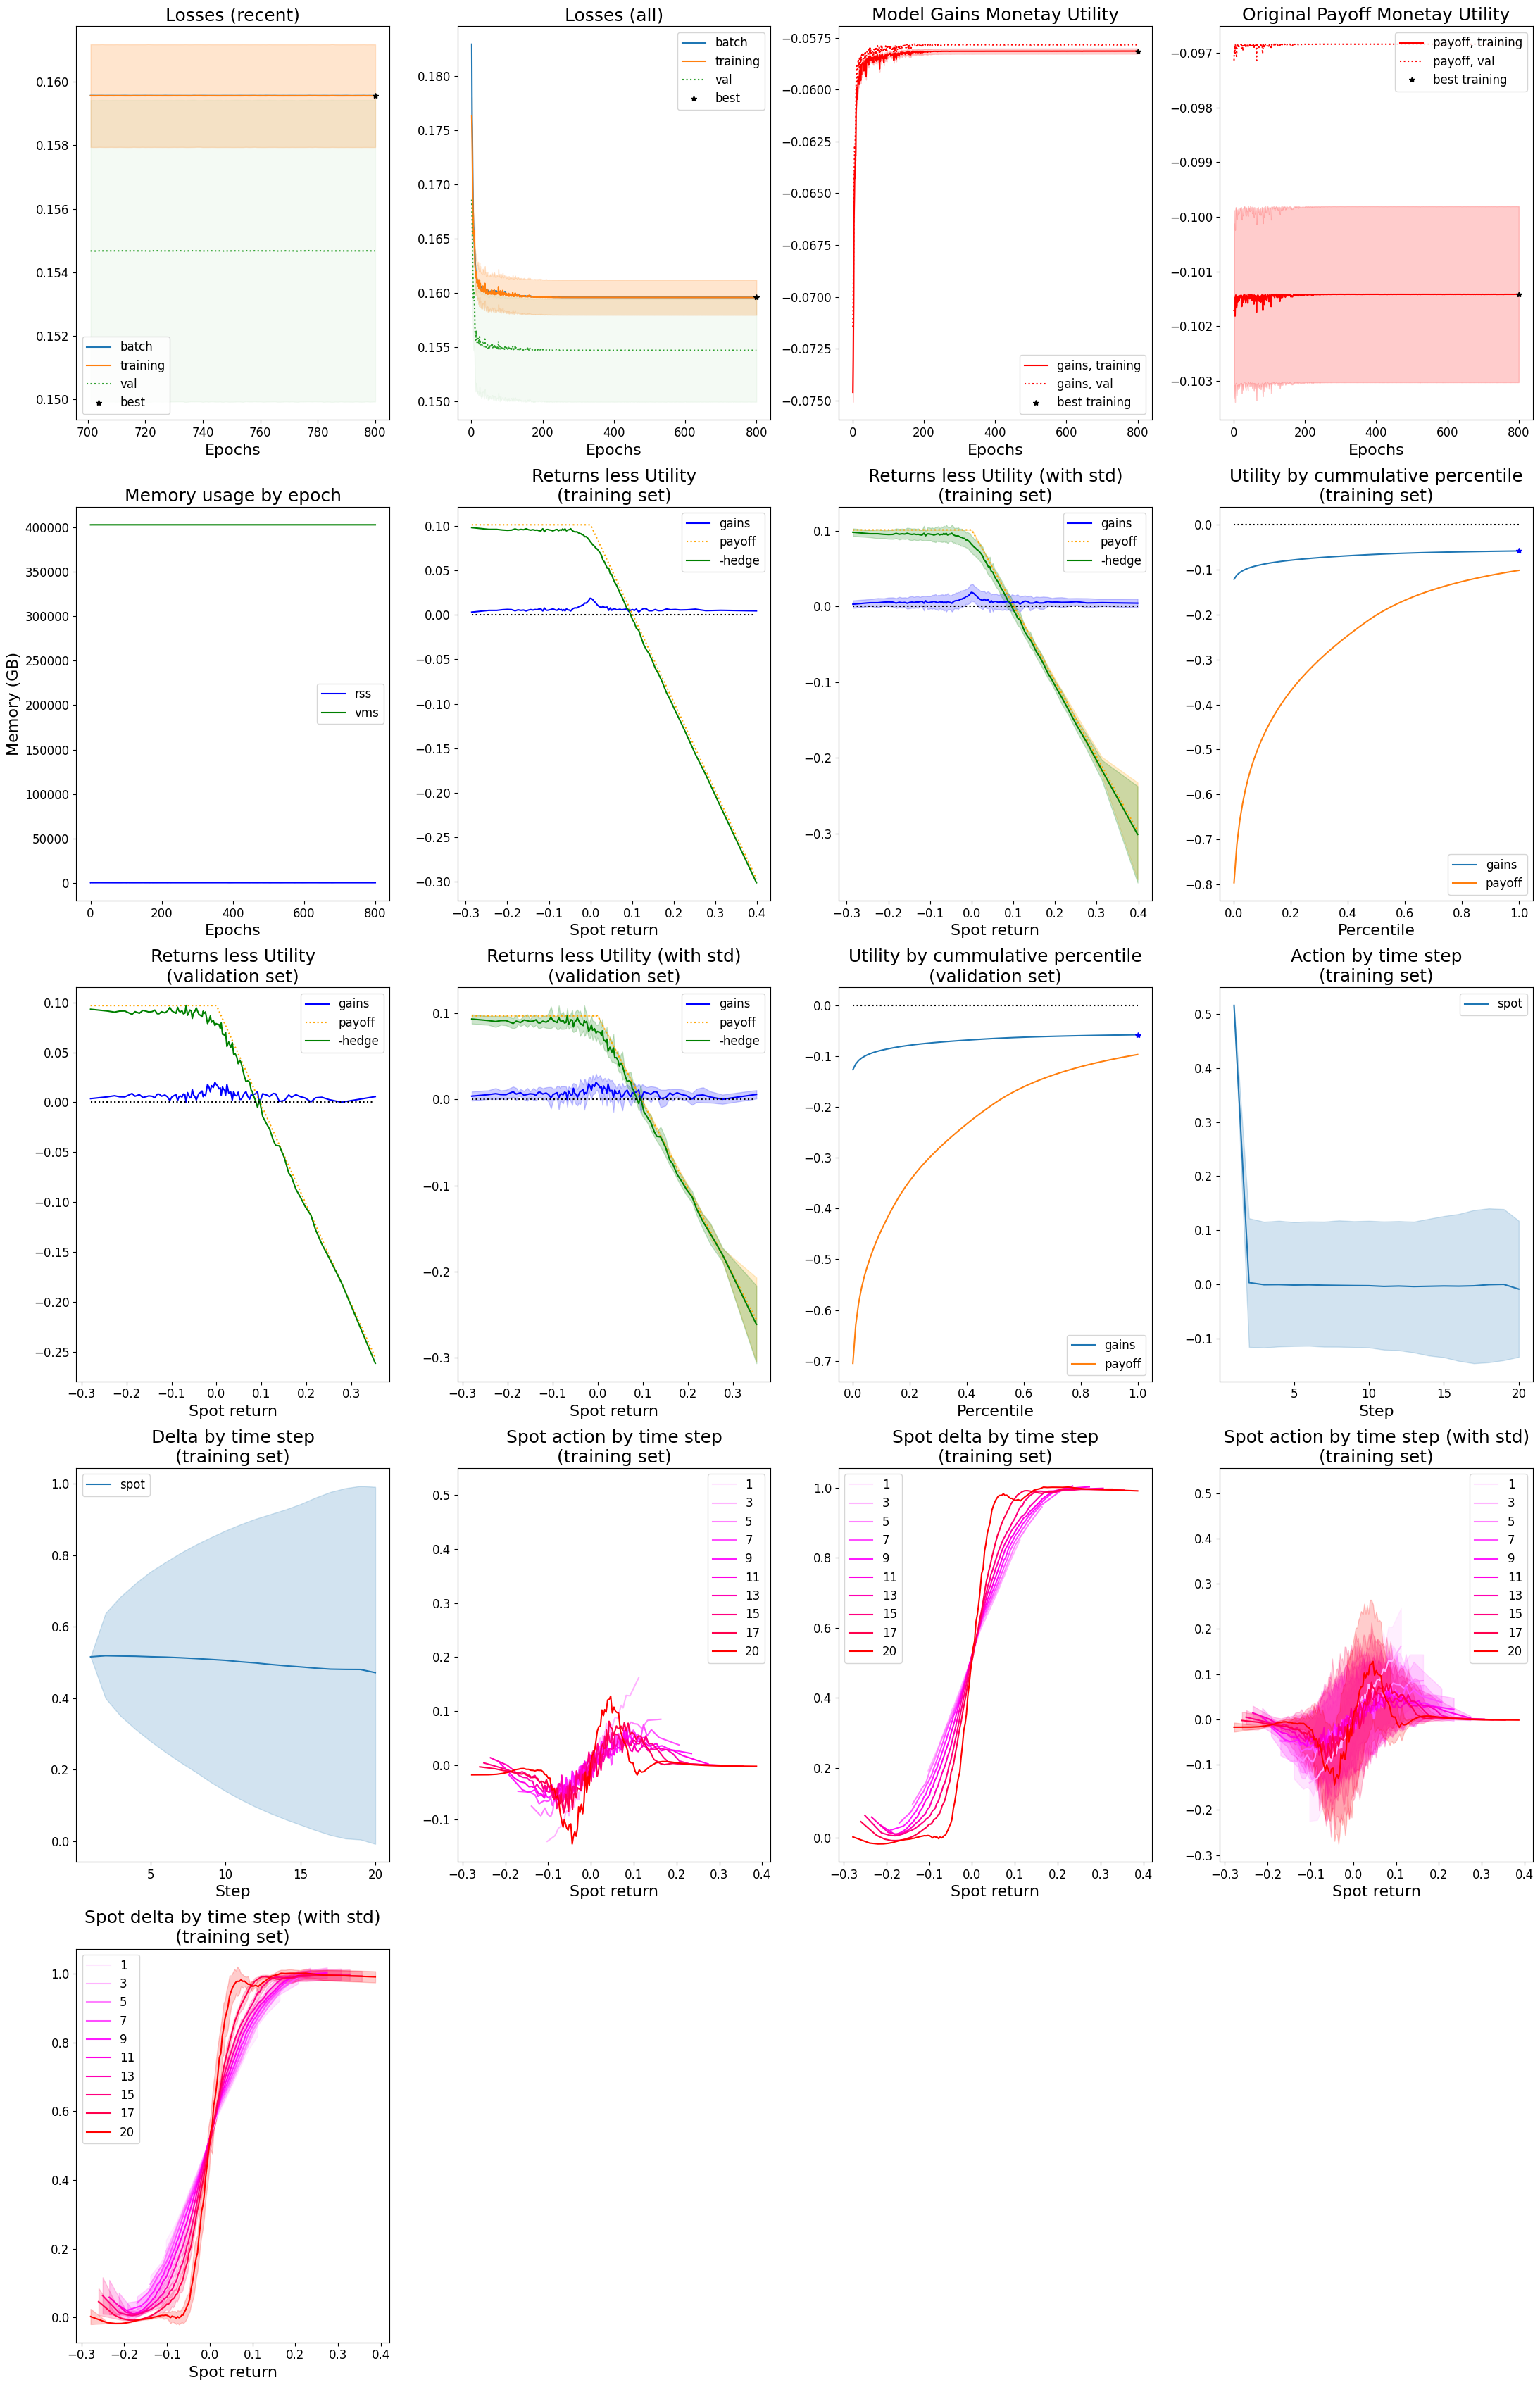

In [5]:
# In your notebook or training script:
import pickle
from deephedging.run_train_torch import run_experiment
from deephedging.plots_proto_torch import plot_full_diagnostics
from deephedging.proto_analysis_torch import resolve_pickle_path

# 1. Load configuration
config = {}
n_prototypes = 100
proto_path = f"./notebooks/prototypes_storage/prototypes_{n_prototypes}.pkl"

# 2. World setup
try:
    with open(resolve_pickle_path(proto_path), "rb") as f:
        prototypes = pickle.load(f)
except FileNotFoundError:
    prototypes = None
    print("Prototype file not found yet; torch will generate it during training.")

results_proto_bs = run_experiment(
    override_world={
        "samples": 10000,
        "steps": 20,
        "black_scholes": True,
    },
    override_model={
        "agent_type": "protopnet",
        "prototype_path": proto_path,
        "feature_list": ["price", "delta", "time_left"],
    },
    override_objective={
        "risk_measure": "cvar",
        "risk_aversion": 1.0,
    },
    override_training={
        "lr": 1e-3,
        "epochs": 800,
        "batch_size": None,
        "epoch_refresh": 5,
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": 0.5,
        "lr_decay_patience": 25,
        "lr_min": 1e-5,
        "scheduler_monitor": "val",
    },
)

config = results_proto_bs["config"]
world = results_proto_bs["world"]
val_world = results_proto_bs["val_world"]
gym = results_proto_bs["gym"]
r = results_proto_bs["training_result"]

print("Keys of the dictionary returned by the gym: ", r.keys())
print("=========================================")
print("Torch config")
print("=========================================")
print(config)

plot_full_diagnostics(results_proto_bs)


## NEW WEIGHTED SIMILARITY


PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.1883 | train 0.1854 | val 0.1771
epoch 5 | batch 0.1765 | train 0.1755 | val 0.1683
epoch 10 | batch 0.1690 | train 0.1681 | val 0.1610
epoch 15 | batch 0.1646 | train 0.1637 | val 0.1581
epoch 20 | batch 0.1633 | train 0.1647 | val 0.1588
epoch 25 | batch 0.1631 | train 0.1636 | val 0.1577
epoch 30 | batch 0.1625 | train 0.1613 | val 0.1561
epoch 35 | batch 0.1617 | train 0.1610 | val 0.1555
epoch 40 | batch 0.1617 | train 0.1609 | val 0.1555
epoch 45 | batch 0.1613 | train 0.1608 | val 0.1555
epoch 50 | batch 0.1611 | train 0.1624 | val 0.1571
epoch 55 | batch 0.1608 | train 0.1603 | val 0.1552
epoch 60 | batch 0.1607 | train 0.1614 | val 0.1560
epoch 65 | batch 0.1607 | train 0.1611 | val 0.1559
epoch 70 | batch 0.1605 | train 0.1608 | val 0.1555
epoch 75 | batch 0.1607 | train 0.1611 | val 0.1560
epoch 80 | batch 0.1605 | train 0.1610 | val 0.1559
epoch 85 | batch 0.1605 | train 0.1601 | val 0.1549
epoch 90 | bat

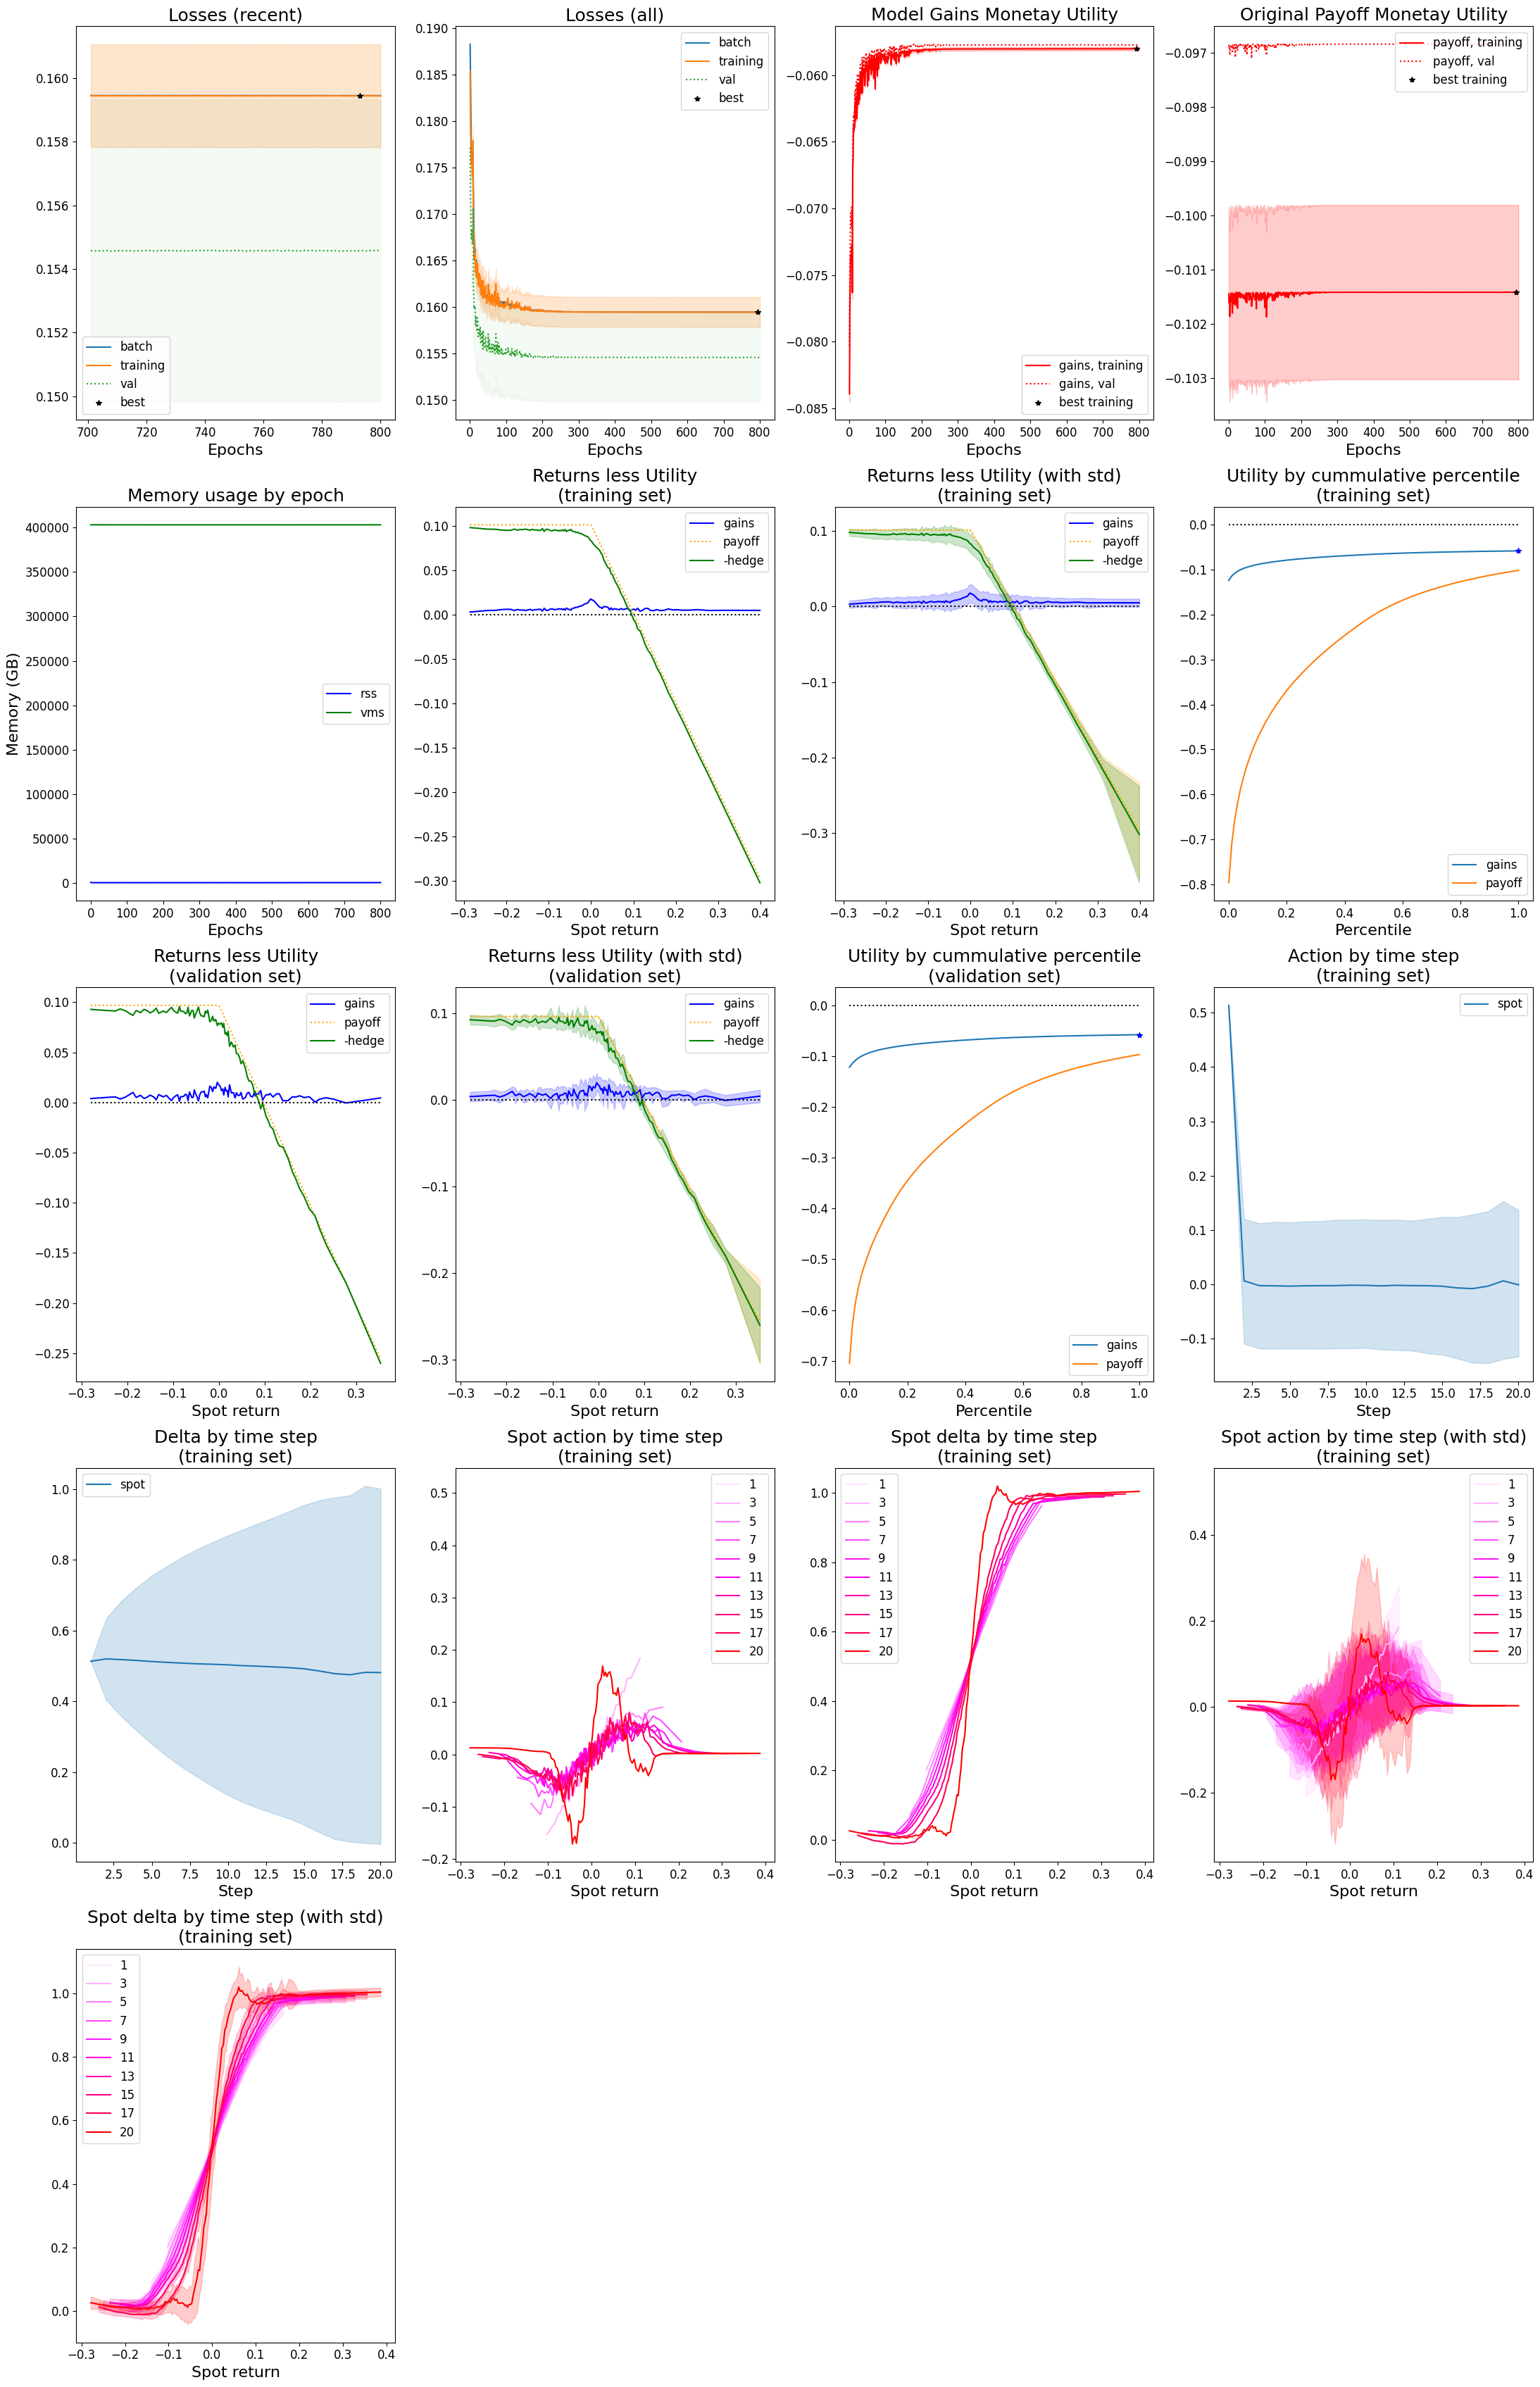

In [6]:
# In your notebook or training script:
import pickle
from deephedging.run_train_torch import run_experiment
from deephedging.plots_proto_torch import plot_full_diagnostics
from deephedging.proto_analysis_torch import resolve_pickle_path

# 1. Load configuration
config = {}
n_prototypes = 100
weighted_proto_path = f"./notebooks/prototypes_storage/prototypes_{n_prototypes}.pkl"

# 2. World setup
try:
    with open(resolve_pickle_path(weighted_proto_path), "rb") as f:
        prototypes = pickle.load(f)
except FileNotFoundError:
    prototypes = None
    print("Prototype file not found yet; torch will generate it during training.")

results_proto_bs_weighted = run_experiment(
    override_world={
        "samples": 10000,
        "steps": 20,
        "black_scholes": True,
    },
    override_model={
        "agent_type": "protopnet",
        "prototype_path": weighted_proto_path,
        "feature_list": ["price", "delta", "time_left"],
        "weighted_similarity": True,
        "distance_feature_weights": [1.0, 1.0, 5.0],
    },
    override_objective={
        "risk_measure": "cvar",
        "risk_aversion": 1.0,
    },
    override_training={
        "lr": 1e-3,
        "epochs": 800,
        "batch_size": None,
        "epoch_refresh": 5,
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": 0.5,
        "lr_decay_patience": 25,
        "lr_min": 1e-5,
        "scheduler_monitor": "val",
    },
)

config = results_proto_bs_weighted["config"]
world = results_proto_bs_weighted["world"]
val_world = results_proto_bs_weighted["val_world"]
gym = results_proto_bs_weighted["gym"]
r = results_proto_bs_weighted["training_result"]

print("Keys of the dictionary returned by the gym: ", r.keys())
print("=========================================")
print("Torch config")
print("=========================================")
print(config)
print("Feature weights:", results_proto_bs_weighted["model"].feature_weights.detach().cpu().numpy())

plot_full_diagnostics(results_proto_bs_weighted)


## Black Scholes Analysis 

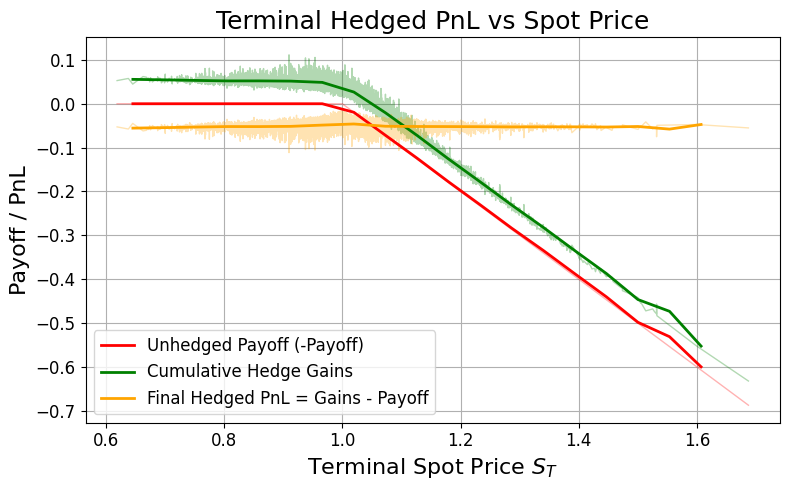

In [7]:
import matplotlib.pyplot as plt
from deephedging.proto_analysis_torch import binned_terminal_pnl

bs_train_analysis = binned_terminal_pnl(
    results_proto_bs_weighted["world"],
    results_proto_bs_weighted["training_result"],
    n_bins=20,
    use_raw_pnl=False,
)

plt.figure(figsize=(8, 5))
plt.plot(bs_train_analysis["sorted_spot_t"], bs_train_analysis["sorted_payoff"], label="_nolegend_", color="red", alpha=0.3, linewidth=1)
plt.plot(bs_train_analysis["sorted_spot_t"], bs_train_analysis["sorted_gains"], label="_nolegend_", color="green", alpha=0.3, linewidth=1)
plt.plot(bs_train_analysis["sorted_spot_t"], bs_train_analysis["sorted_total"], label="_nolegend_", color="orange", alpha=0.3, linewidth=1)

plt.plot(bs_train_analysis["bin_centers"], bs_train_analysis["payoff_binned"], label="Unhedged Payoff (-Payoff)", color="red", linewidth=2)
plt.plot(bs_train_analysis["bin_centers"], bs_train_analysis["gains_binned"], label="Cumulative Hedge Gains", color="green", linewidth=2)
plt.plot(bs_train_analysis["bin_centers"], bs_train_analysis["total_binned"], label="Final Hedged PnL = Gains - Payoff", color="orange", linewidth=2)

plt.xlabel("Terminal Spot Price $S_T$")
plt.ylabel("Payoff / PnL")
plt.title("Terminal Hedged PnL vs Spot Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Running strategies ...done


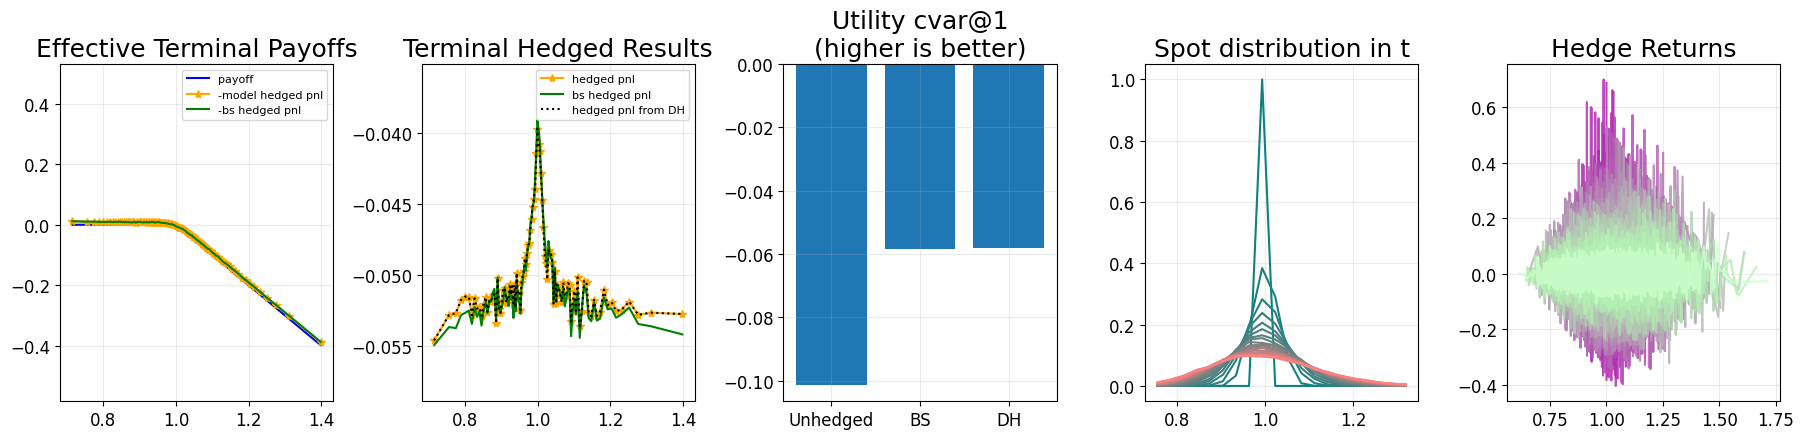

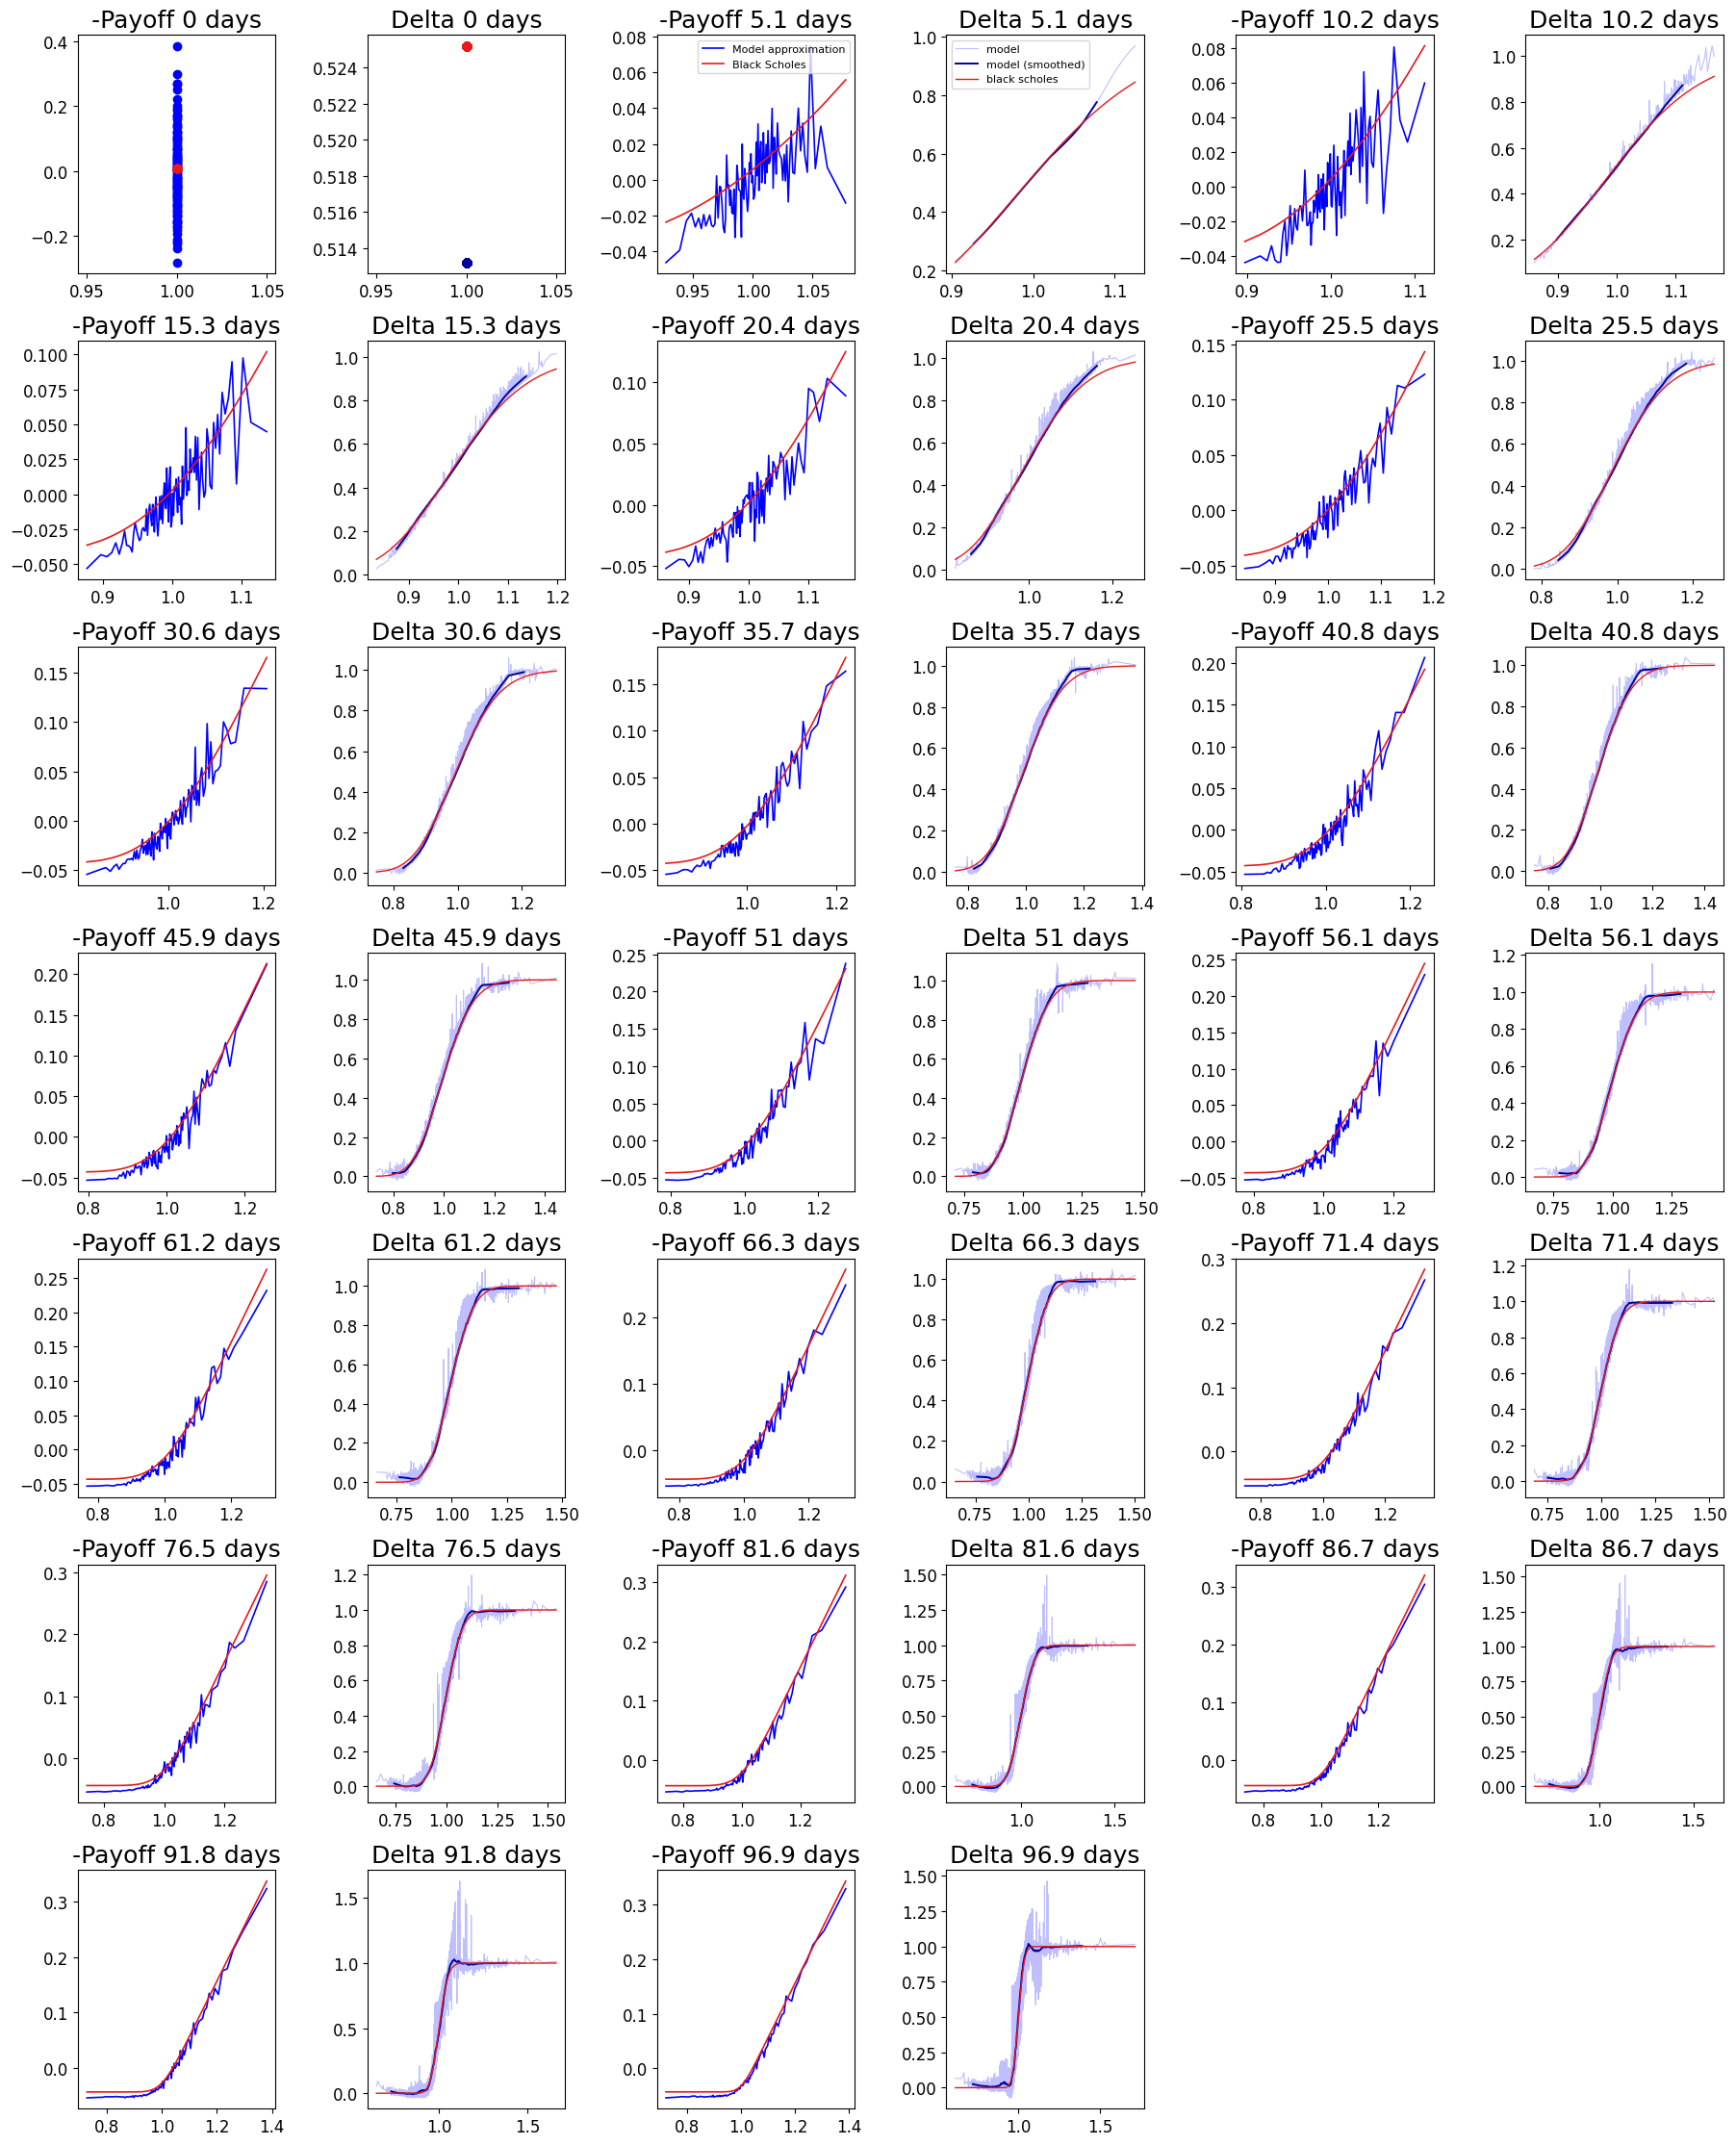

In [8]:
import deephedging.plot_bs_hedge_torch as plot_bs_hedge
plot_bs_hedge.plot_blackscholes(
    results_proto_bs_weighted["world"],
    results_proto_bs_weighted["gym"],
    results_proto_bs_weighted["config"],
)


## Black Scholes Inference

In [9]:
# import torch
# import numpy as np
# from deephedging.base_torch import torchCast
#
# # 1. Generate 5000 new test samples from same world
# test_world = world.clone(samples=5000)
# test_data = torchCast(test_world.torch_data)
# with torch.no_grad():
#     test_result = gym.forward(test_data, training=False, return_paths=True)
#     test_result_vanilla = gym_vanilla.forward(test_data, training=False, return_paths=True)


In [10]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)


FIRST VERIFY IF THE PATH WAS PROFITABLE BEFOFE PRINTING THE PATH

In [11]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

path_num = globals().get("path_num", -1500)
bs_test_result["utility0"][path_num], bs_test_result["utility"][path_num]


(tensor(-0.1268), tensor(-0.0514))

In [12]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import numpy as np
from deephedging.proto_analysis_torch import bs_similarity_details

bs_path_details = bs_similarity_details(
    agent=results_proto_bs_weighted["model"],
    world=bs_test_world,
    result=bs_test_result,
    prototype_path=weighted_proto_path,
    path_num=path_num,
    top_k=3,
)

for row in bs_path_details["rows"]:
    print()
    print(f"Step {row['step']}:")
    print(
        "  Input:        "
        f"delta={row['input']['delta']:.3f}, price={row['input']['price']:.3f}, time_left={row['input']['time_left']:.3f}"
    )
    print(f"  Action:       {row['action']:.4f}")
    print("  Top 3 Prototypes:")
    for j, idx in enumerate(row["top_indices"]):
        action_j = np.asarray(row["top_actions"][j]).reshape(-1)[0]
        print(
            f"    - Prototype {int(idx)} | Features={np.round(row['top_prototypes'][j], 3)} "
            f"| Action={action_j:.4f} | Similarity={row['top_similarities'][j]:.3f}"
        )



Step 0:
  Input:        delta=0.000, price=1.000, time_left=0.400
  Action:       0.5132
  Top 3 Prototypes:
    - Prototype 39 | Features=[0.333 0.983 0.036] | Action=0.5668 | Similarity=0.886
    - Prototype 31 | Features=[0.447 0.994 0.036] | Action=0.4449 | Similarity=0.027
    - Prototype 6 | Features=[0.508 1.    0.04 ] | Action=0.2727 | Similarity=0.025

Step 1:
  Input:        delta=0.513, price=1.000, time_left=0.380
  Action:       0.0086
  Top 3 Prototypes:
    - Prototype 6 | Features=[0.508 1.    0.04 ] | Action=0.2727 | Similarity=0.605
    - Prototype 36 | Features=[0.538 1.003 0.036] | Action=-0.4823 | Similarity=0.342
    - Prototype 44 | Features=[0.498 0.999 0.032] | Action=-0.1345 | Similarity=0.020

Step 2:
  Input:        delta=0.522, price=1.029, time_left=0.360
  Action:       0.0888
  Top 3 Prototypes:
    - Prototype 6 | Features=[0.508 1.    0.04 ] | Action=0.2727 | Similarity=0.612
    - Prototype 36 | Features=[0.538 1.003 0.036] | Action=-0.4823 | Similar

Number of zero payoffs: 2638 / 5000


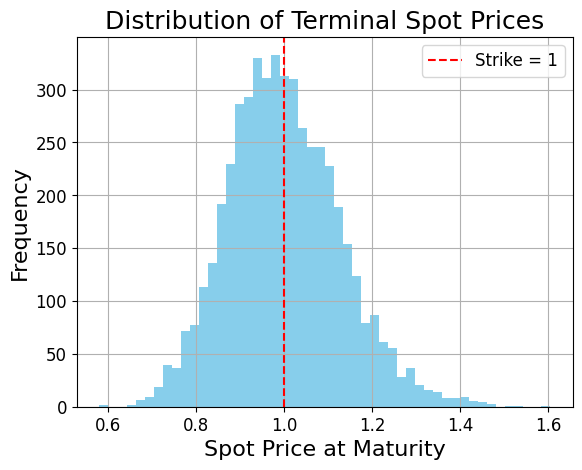

In [13]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import numpy as np
import matplotlib.pyplot as plt

terminal_spots = bs_test_world.details.spot_all[:, -1]
payoffs = bs_test_result["payoff"].numpy()

n_zero_payoffs = np.sum(np.isclose(payoffs, 0))
print(f"Number of zero payoffs: {n_zero_payoffs} / {len(payoffs)}")

plt.hist(terminal_spots, bins=50, color="skyblue")
plt.axvline(1.0, color="red", linestyle="--", label="Strike = 1")
plt.title("Distribution of Terminal Spot Prices")
plt.xlabel("Spot Price at Maturity")
plt.ylabel("Frequency")
plt.grid(True)
plt.legend()
plt.show()


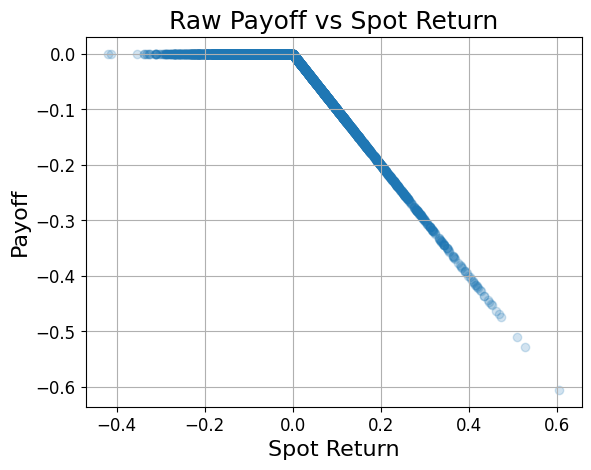

In [14]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

spot_return = bs_test_world.details.spot_all[:, -1] - 1.0
payoff = bs_test_result["payoff"].numpy()

import matplotlib.pyplot as plt
plt.scatter(spot_return, payoff, alpha=0.2)
plt.xlabel("Spot Return")
plt.ylabel("Payoff")
plt.title("Raw Payoff vs Spot Return")
plt.grid(True)
plt.show()

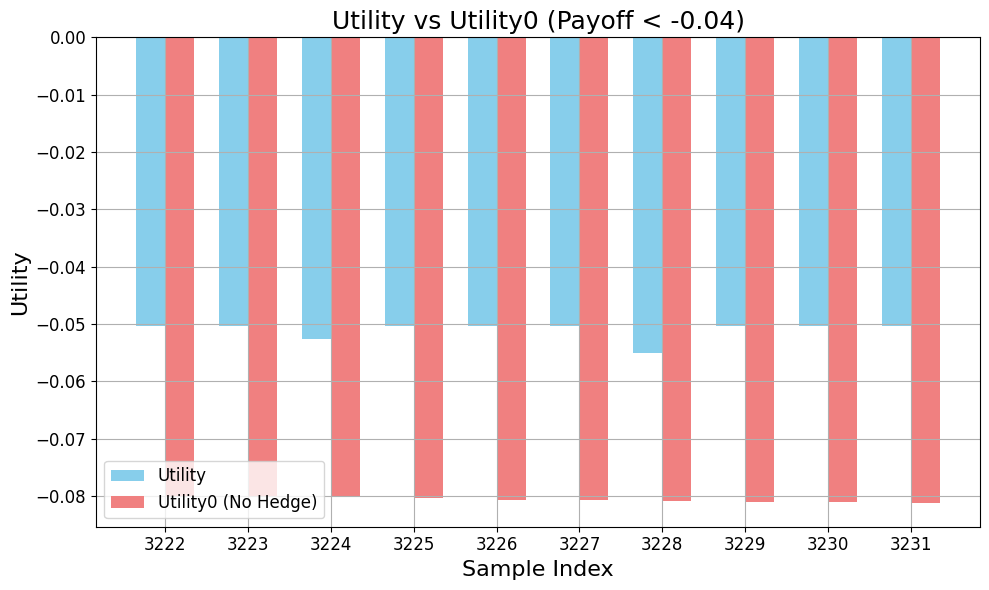

In [15]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import matplotlib.pyplot as plt
import numpy as np

# Extract utility, utility0, and payoff
utility = bs_test_result["utility"].numpy()
utility0 = bs_test_result["utility0"].numpy()
payoff = bs_test_result["payoff"].numpy()

# Find indices where payoff < 0 (i.e., short option was exercised)
negative_payoff_indices = np.where(payoff <= -0.04)[0]

# Take the first 10 of those
selected_indices = negative_payoff_indices[:10]
if len(selected_indices) == 0:
    print("No samples with payoff < -0.04 found.")
else:
    bar_width = 0.35
    indices = np.arange(len(selected_indices))

    plt.figure(figsize=(10, 6))
    plt.bar(indices, utility[selected_indices], width=bar_width, label='Utility', color='skyblue')
    plt.bar(indices + bar_width, utility0[selected_indices], width=bar_width, label='Utility0 (No Hedge)', color='lightcoral')

    plt.xlabel("Sample Index")
    plt.ylabel("Utility")
    plt.title("Utility vs Utility0 (Payoff < -0.04)")
    plt.xticks(indices + bar_width / 2, [str(i) for i in selected_indices])
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

/opt/anaconda3/envs/dh/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


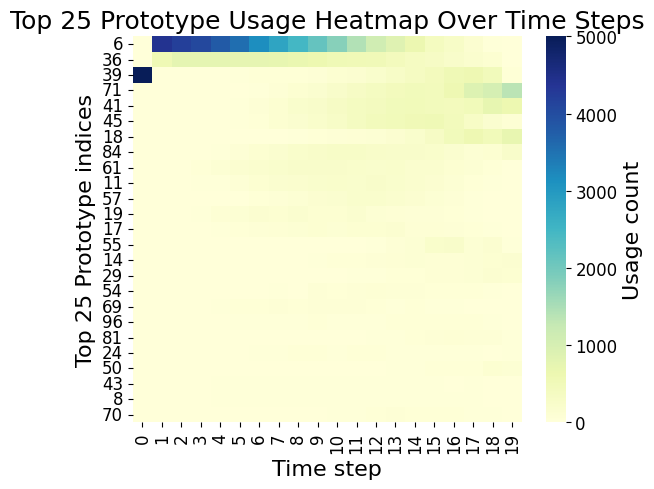

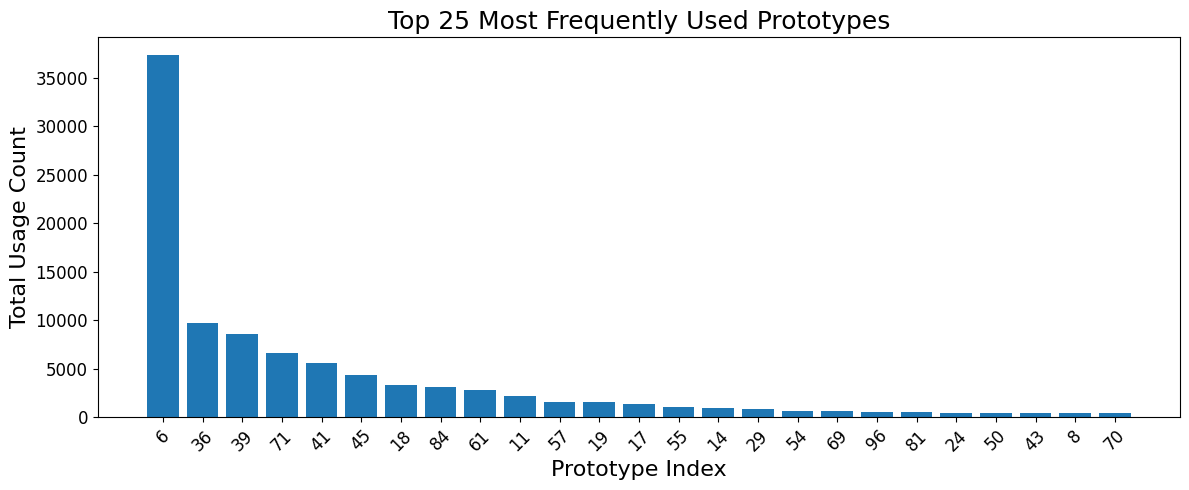

In [16]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import matplotlib.pyplot as plt
import seaborn as sns
from deephedging.proto_analysis_torch import bs_prototype_usage

bs_usage = bs_prototype_usage(
    agent=results_proto_bs_weighted["model"],
    world=bs_test_world,
    result=bs_test_result,
    prototype_path=weighted_proto_path,
    top_n=25,
)

globals()["bs_usage"] = bs_usage
heatmap = bs_usage["heatmap"]
top_25_idx = bs_usage["top_indices"]
filtered_heatmap = bs_usage["top_heatmap"]
totals = bs_usage["totals"]
top_25_vals = bs_usage["top_totals"]

plt.figure(figsize=(6, 5))
sns.heatmap(filtered_heatmap, cmap="YlGnBu", cbar_kws={"label": "Usage count"}, yticklabels=top_25_idx)
plt.xlabel("Time step")
plt.ylabel("Top 25 Prototype indices")
plt.title("Top 25 Prototype Usage Heatmap Over Time Steps")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(range(25), top_25_vals, tick_label=top_25_idx)
plt.xlabel("Prototype Index")
plt.ylabel("Total Usage Count")
plt.title("Top 25 Most Frequently Used Prototypes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [17]:
from deephedging.proto_analysis_torch import ensure_bs_test_context, bs_prototype_usage, load_prototype_payload

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

bs_usage = globals().get("bs_usage")
if bs_usage is None:
    bs_usage = bs_prototype_usage(
        agent=results_proto_bs_weighted["model"],
        world=bs_test_world,
        result=bs_test_result,
        prototype_path=weighted_proto_path,
        top_n=25,
    )
    globals()["bs_usage"] = bs_usage

top_25_idx = bs_usage["top_indices"]

import numpy as np
import pandas as pd
from IPython.display import display

payload = load_prototype_payload(weighted_proto_path)
scaler = payload["scaler"]
prototypes_np = payload["prototypes"]
proto_actions_np = results_proto_bs_weighted["model"].prototype_actions.detach().cpu().numpy()

top_10_idx = np.array(top_25_idx[:10], dtype=int)
top_10_prototypes = prototypes_np[top_10_idx]
top_10_actions = proto_actions_np[top_10_idx]
original_features = scaler.inverse_transform(top_10_prototypes)

df = pd.DataFrame(original_features, columns=["delta", "price", "time_left"])
df["action"] = top_10_actions[:, 0]
df["prototype_index"] = top_10_idx

df = df[["prototype_index", "delta", "price", "time_left", "action"]]

display(df.style.set_caption("Top 10 Most-Used Prototypes with Features and Actions"))


/opt/anaconda3/envs/dh/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


,prototype_index,delta,price,time_left,action
0,6,0.507947,1.000000,0.039683,0.272694
1,36,0.538353,1.002929,0.035714,-0.482316
2,39,0.332524,0.983067,0.035714,0.566817
3,71,0.000007,0.925328,0.007937,0.012857
4,41,0.994755,1.074336,0.019841,0.015700
5,45,0.015204,0.946614,0.015873,0.261675
6,18,1.000000,1.130747,0.007937,0.002124
7,84,0.054687,0.947505,0.027778,0.105019
8,61,0.623284,1.011221,0.035714,-0.244080
9,11,0.699871,1.019276,0.035714,-0.007184


/opt/anaconda3/envs/dh/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


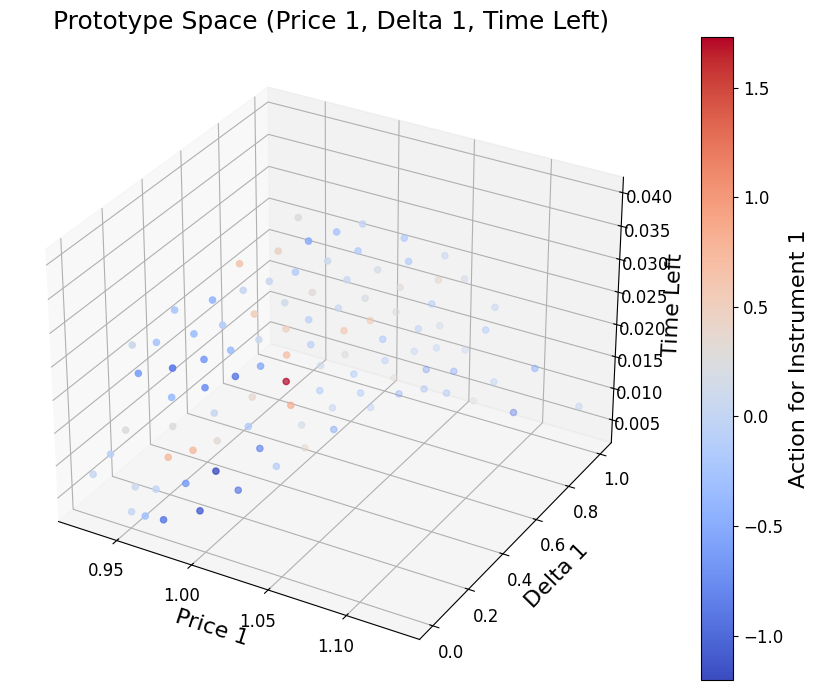

In [18]:
from deephedging.proto_analysis_torch import ensure_bs_test_context, load_prototype_payload

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

payload = load_prototype_payload(weighted_proto_path)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_bs_weighted["model"].prototype_actions.detach().cpu().numpy()

prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 1]
delta_1 = prototypes_raw[:, 0]
time_left = prototypes_raw[:, 2]
action_1 = proto_actions[:, 0]

globals()["price_1"] = price_1
globals()["delta_1"] = delta_1
globals()["time_left"] = time_left
globals()["action_1"] = action_1

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', s=20)

ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
fig.colorbar(p, ax=ax, label="Action for Instrument 1")
ax.set_title("Prototype Space (Price 1, Delta 1, Time Left)")

plt.tight_layout()
plt.show()


/opt/anaconda3/envs/dh/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


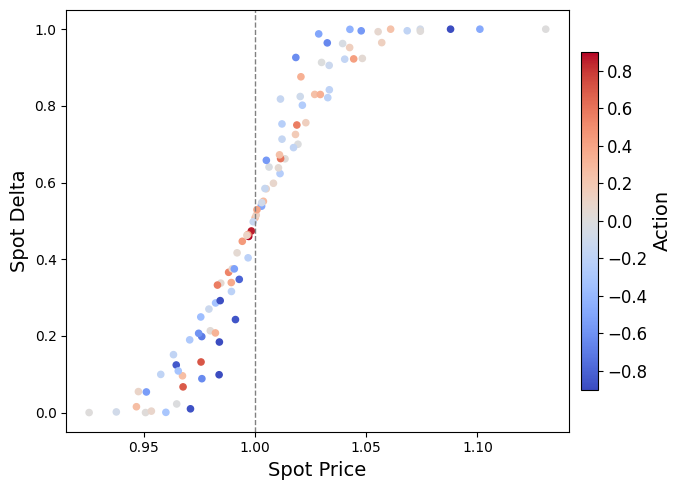

In [19]:
from deephedging.proto_analysis_torch import ensure_bs_test_context, load_prototype_payload

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

payload = load_prototype_payload(weighted_proto_path)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_bs_weighted["model"].prototype_actions.detach().cpu().numpy()
prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 1]
delta_1 = prototypes_raw[:, 0]
action_1 = proto_actions[:, 0]

# Set symmetric color limits around 0
abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

plt.figure(figsize=(7, 5))
sc = plt.scatter(price_1, delta_1, c=action_1, cmap='coolwarm', norm=norm, s=20)
plt.xlabel("Spot Price", fontsize=14)
plt.ylabel("Spot Delta", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=1)

cbar = plt.colorbar(sc, shrink=0.8, pad=0.02)
cbar.set_label("Action", fontsize=14)

plt.tight_layout()
plt.show()


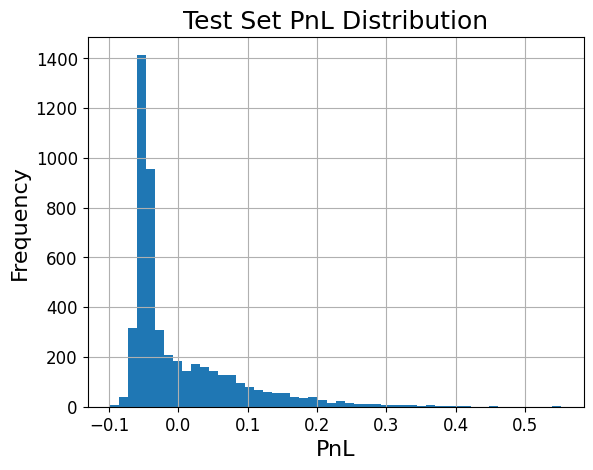

In [20]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

## PNL PLOT

plt.hist(bs_test_result["pnl"].numpy(), bins=50)
plt.title("Test Set PnL Distribution")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [21]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

bs_test_result["pnl"].numpy().mean()

np.float32(0.00051124877)

In [22]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import numpy as np

utility = bs_test_result["utility"].numpy()
utility0 = bs_test_result["utility0"].numpy()

# Count how many times utility > utility0
n_better = np.sum(utility > utility0)
total = len(utility)

print(f"Utility is higher than Utility0 in {n_better} out of {total} samples ({n_better / total:.2%})")

Utility is higher than Utility0 in 1907 out of 5000 samples (38.14%)


Running strategies ...done


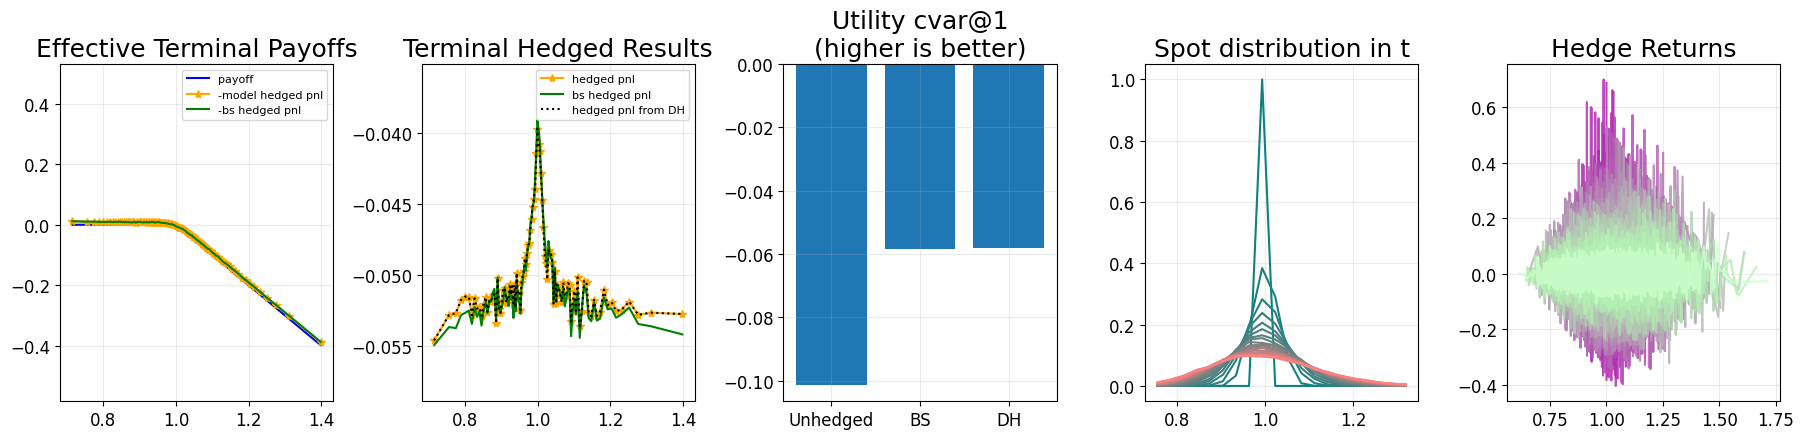

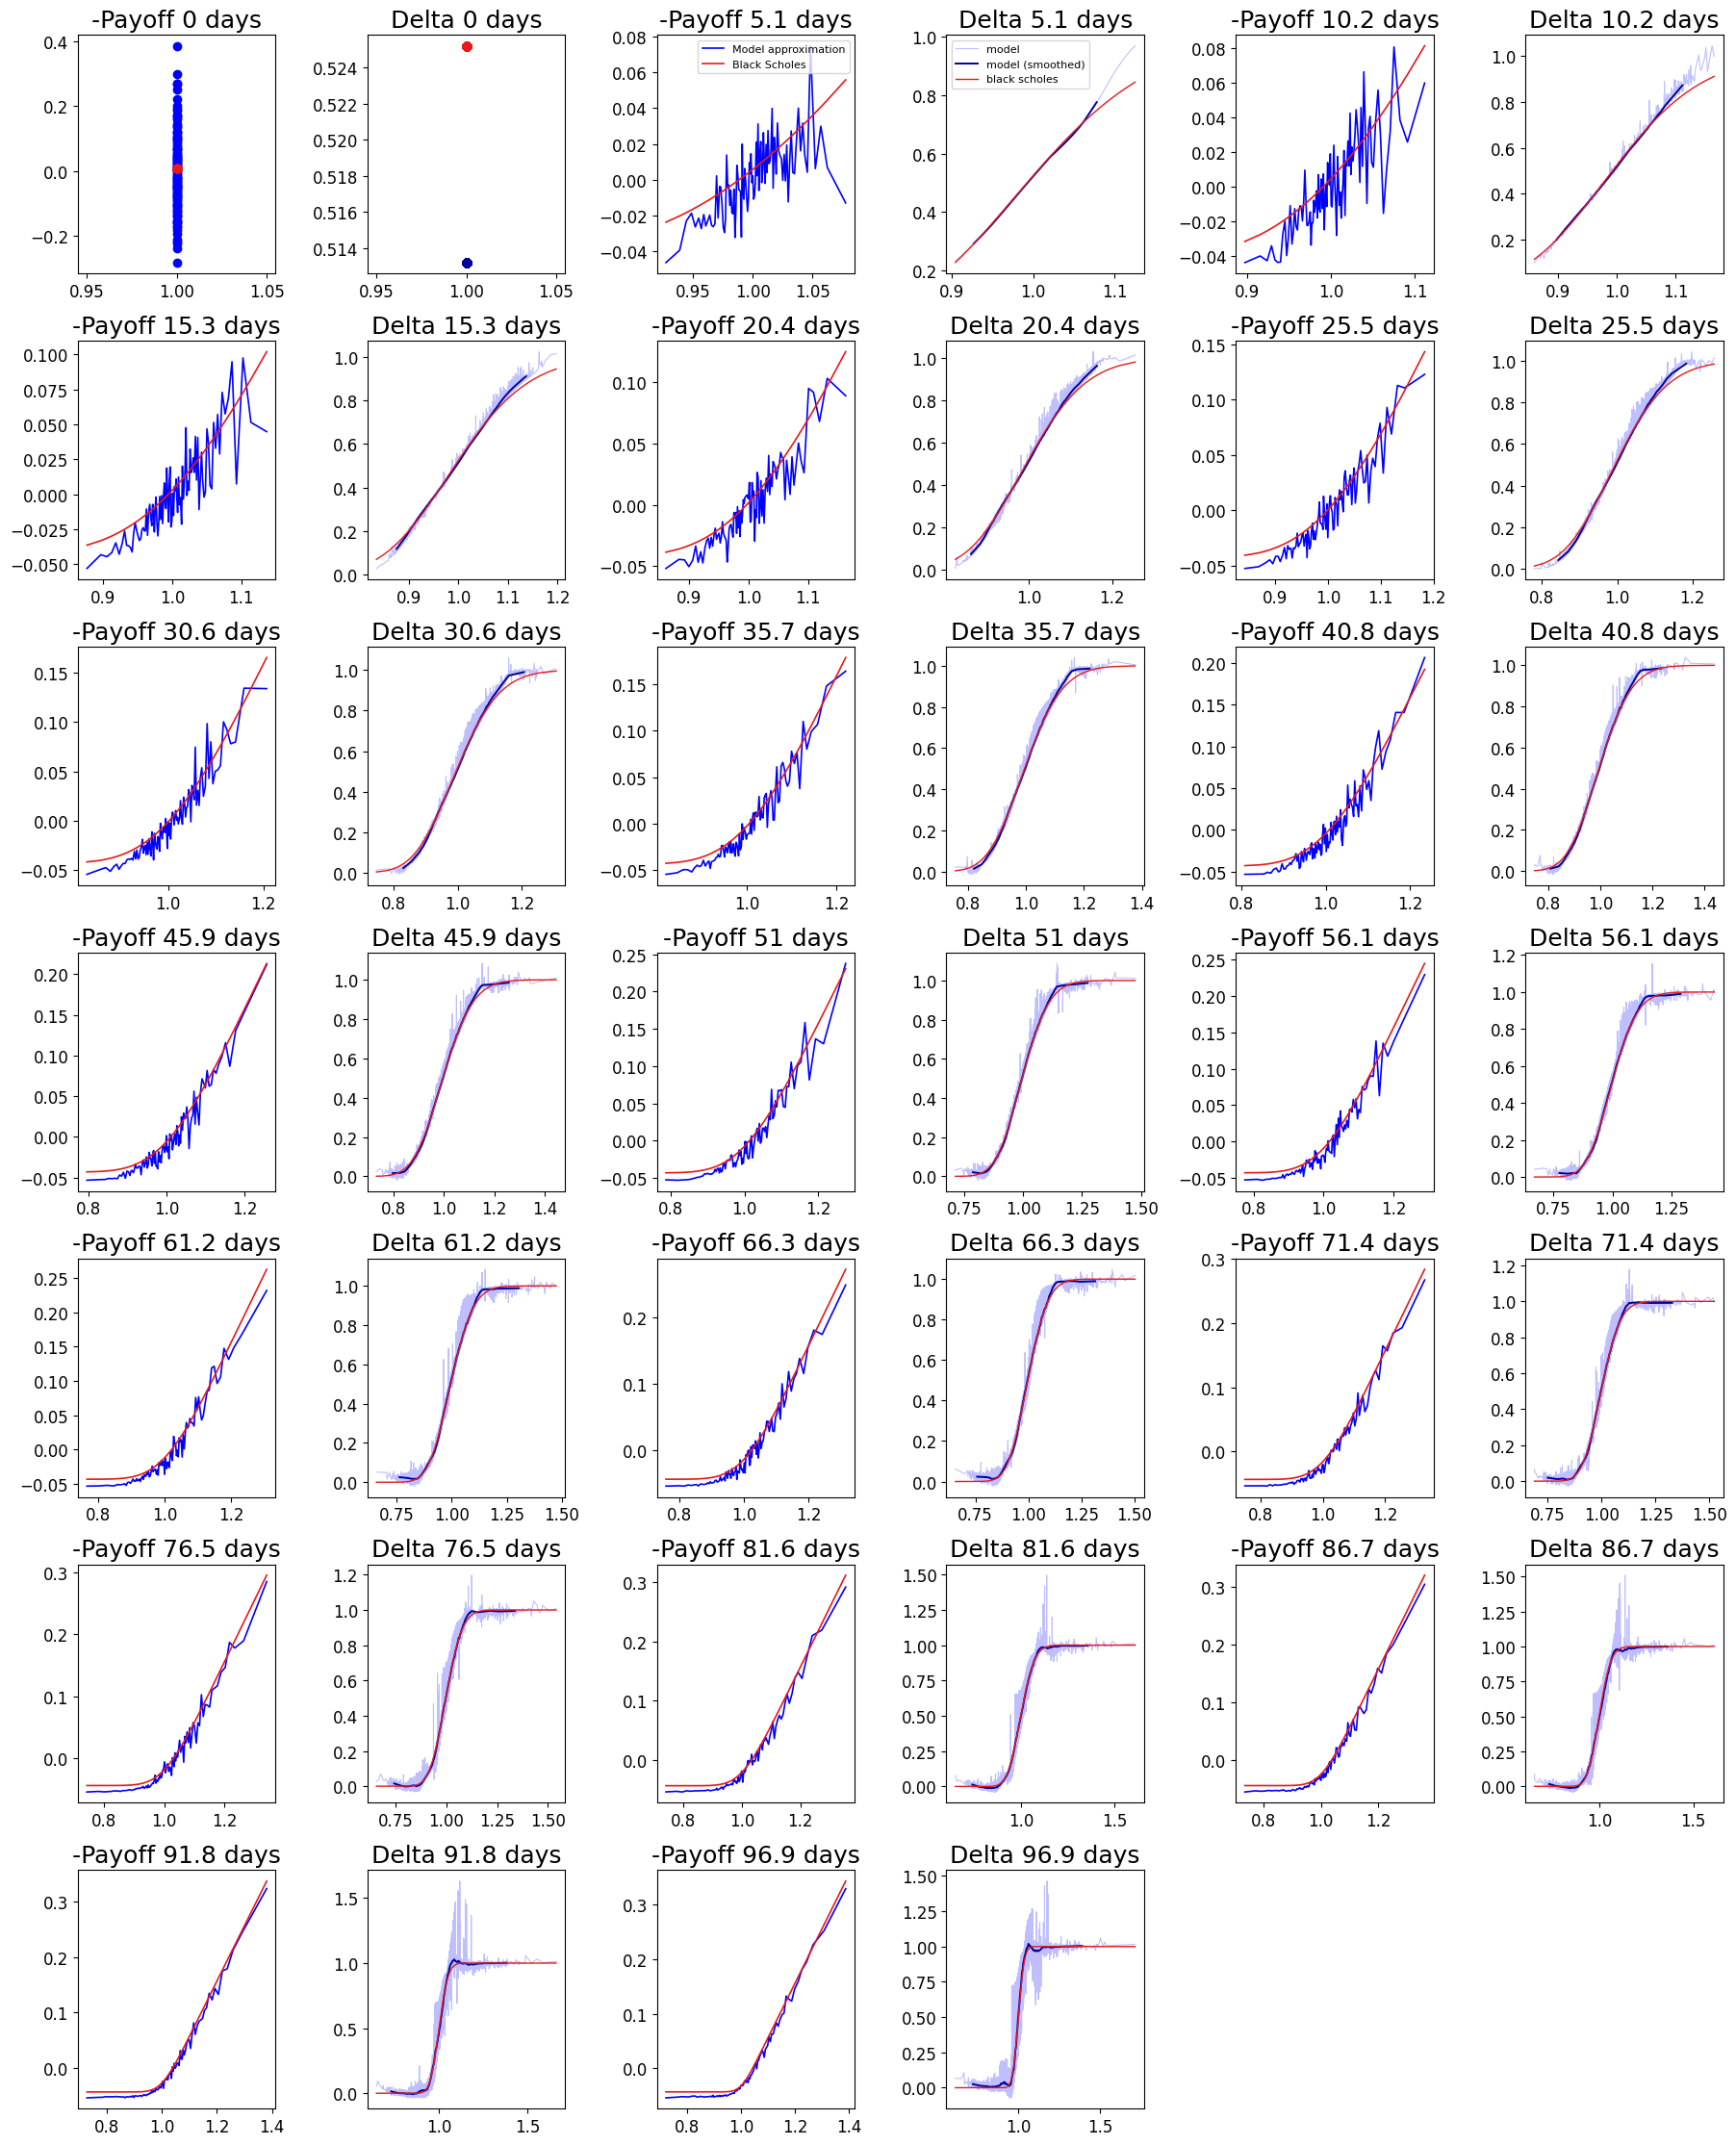

In [23]:
import deephedging.plot_bs_hedge_torch as plot_bs_hedge
plot_bs_hedge.plot_blackscholes(
    results_proto_bs_weighted["world"],
    results_proto_bs_weighted["gym"],
    results_proto_bs_weighted["config"],
)


In [24]:
# # 1. Generate 5000 new test samples from same world
# bs_test_world = world.clone(samples=10000)
# bs_test_data = torchCast(bs_test_world.torch_data)
# with torch.no_grad():
#     bs_test_result = gym.forward(bs_test_data, training=False, return_paths=True)
#     bs_test_result_vanilla = gym_vanilla.forward(bs_test_data, training=False, return_paths=True)


In [25]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

print("PROTOTYPE-BASED STATS : ")
print("Mean Utility (unhedged):", bs_test_result["utility0"].numpy().mean())
print("Mean Utility (hedged):", bs_test_result["utility"].numpy().mean())
print("payoff", bs_test_result["payoff"].numpy().mean())
print("gains", bs_test_result["gains"].numpy().mean())
print("pnl", bs_test_result["pnl"].numpy().mean())
print("")

print("VANILLA STATS : ")
print("Mean Utility (unhedged):", bs_test_result_vanilla["utility0"].numpy().mean())
print("Mean Utility (hedged):", bs_test_result_vanilla["utility"].numpy().mean())
print("payoff", bs_test_result_vanilla["payoff"].numpy().mean())
print("gains", bs_test_result_vanilla["gains"].numpy().mean())
print("pnl", bs_test_result_vanilla["pnl"].numpy().mean())

PROTOTYPE-BASED STATS : 
Mean Utility (unhedged): -0.10175825
Mean Utility (hedged): -0.05823597
payoff -0.050879046
gains -0.050746337
pnl 0.00051124877

VANILLA STATS : 
Mean Utility (unhedged): -0.10175876
Mean Utility (hedged): -0.060352955
payoff -0.050879046
gains -0.050669804
pnl 0.0005751984


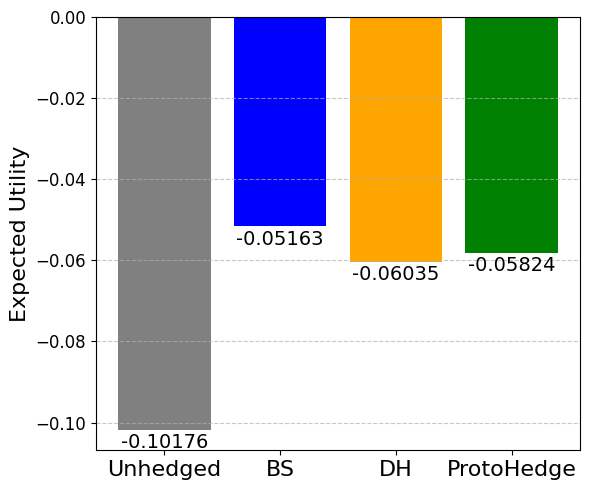

In [26]:
from deephedging.proto_analysis_torch import ensure_bs_test_context

bs_test_world, bs_test_result, bs_test_result_vanilla, results_bs = ensure_bs_test_context(
    results_proto_bs_weighted=results_proto_bs_weighted,
    results_bs=globals().get("results_bs"),
    seed=1,
    samples=5000,
)

import matplotlib.pyplot as plt

# Utilities
utilities = {
    'Unhedged': bs_test_result_vanilla["utility0"].numpy().mean(),
    'BS': -0.0516349,
    'DH': bs_test_result_vanilla["utility"].numpy().mean(),
    'ProtoHedge': bs_test_result["utility"].numpy().mean()
}

labels = list(utilities.keys())
values = list(utilities.values())
colors = ['gray', 'blue', 'orange', 'green']

# Plot
plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=colors)

plt.ylabel('Expected Utility', fontsize=16)
plt.xticks(fontsize=16)
# plt.title('Expected Utility Comparison (CVaR@50%) in Black-Scholes World')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add black text below the top of each bar
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, val - 0.0055, f"{val:.5f}",
             ha='center', va='bottom', color='black', fontsize=14)

plt.tight_layout()
plt.show()

# Stochastic Volatility World

## Vanilla DH - No intial Delta

In [27]:
print("Deep Hedging AI says hello  ... ", end='')
from IPython.display import display, Markdown
from deephedging.run_train_torch import run_experiment


display(Markdown("## Deep Hedging in a simple Stochastic Volatility World"))

results_stoch_vanilla = run_experiment(
    override_world={
        "samples": 10000,
        "steps": 20,
        "black_scholes": False,
    },
    override_objective={
        "risk_measure": "cvar",
        "risk_aversion": 1.0,
    },
    override_model={
        "agent_type": "feed_forward",
        "feature_list": ["price", "delta", "time_left"],
        "network_depth": 3,
        "network_width": 20,
        "activation": "softplus",
    },
    override_training={
        "lr": 1e-3,
        "batch_size": None,
        "epochs": 800,
        "epoch_refresh": 5,
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": 0.5,
        "lr_decay_patience": 25,
        "lr_min": 1e-5,
        "scheduler_monitor": "val",
    },
)

config = results_stoch_vanilla["config"]
world = results_stoch_vanilla["world"]
val_world = results_stoch_vanilla["val_world"]
vanilla_stoch_gym = results_stoch_vanilla["gym"]
vanilla_stoch_model = vanilla_stoch_gym
r = results_stoch_vanilla["training_result"]

print("Keys of the dictionary returned by the gym: ", r.keys())
print("=========================================")
print("Torch config")
print("=========================================")
print(config)


Deep Hedging AI says hello  ... 

## Deep Hedging in a simple Stochastic Volatility World


PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.2417 | train 0.2317 | val 0.2423
epoch 5 | batch 0.2241 | train 0.2231 | val 0.2327
epoch 10 | batch 0.2165 | train 0.2149 | val 0.2226
epoch 15 | batch 0.2146 | train 0.2139 | val 0.2215
epoch 20 | batch 0.2144 | train 0.2156 | val 0.2226
epoch 25 | batch 0.2140 | train 0.2132 | val 0.2204
epoch 30 | batch 0.2140 | train 0.2133 | val 0.2207
epoch 35 | batch 0.2139 | train 0.2141 | val 0.2210
epoch 40 | batch 0.2138 | train 0.2133 | val 0.2203
epoch 45 | batch 0.2139 | train 0.2131 | val 0.2202
epoch 50 | batch 0.2138 | train 0.2134 | val 0.2206
epoch 55 | batch 0.2137 | train 0.2135 | val 0.2208
epoch 60 | batch 0.2135 | train 0.2130 | val 0.2202
epoch 65 | batch 0.2139 | train 0.2132 | val 0.2204
epoch 70 | batch 0.2139 | train 0.2139 | val 0.2211
epoch 75 | batch 0.2135 | train 0.2130 | val 0.2202
epoch 80 | batch 0.2134 | train 0.2142 | val 0.2214
epoch 85 | batch 0.2140 | train 0.2132 | val 0.2203
epoch 90 | bat

## Prototype-based Stochastic Volatility World

In [28]:
print("Deep Hedging AI says hello  ... ", end='')
import pickle
from pathlib import Path
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from threadpoolctl import threadpool_limits
from IPython.display import display, Markdown
from deephedging.run_train_torch import run_experiment
from deephedging.proto_analysis_torch import resolve_pickle_path

# ============================
# 1. Load configuration
config = {}

n_prototypes = 500
prototype_path_stoch = f"./notebooks/prototypes_storage/prototypes_stochastic_{n_prototypes}.pkl"

try:
    resolved_proto_path = resolve_pickle_path(prototype_path_stoch)
except FileNotFoundError:
    resolved_proto_path = Path("notebooks/prototypes_storage") / f"prototypes_stochastic_{n_prototypes}.pkl"

if not resolved_proto_path.exists():
    print("Stochastic prototype file not found; building it from the vanilla stochastic policy.")
    price = world.data.features.per_step['price']
    time_left = world.data.features.per_step['time_left']
    actions = results_stoch_vanilla['training_result']['actions'].numpy()
    delta = np.cumsum(actions, axis=1) - actions

    X_all = np.stack(
        [
            delta[:, :, 0],
            delta[:, :, 1],
            price[:, :, 0],
            price[:, :, 1],
            time_left,
        ],
        axis=2,
    ).reshape(-1, 5)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_all)

    with threadpool_limits(limits=1):
        kmeans = KMeans(n_clusters=n_prototypes, random_state=0, n_init="auto")
        labels = kmeans.fit_predict(X_scaled)
        real_prototypes = []
        for cluster_idx in range(n_prototypes):
            cluster_points = X_scaled[labels == cluster_idx]
            if len(cluster_points) == 0:
                continue
            center = kmeans.cluster_centers_[cluster_idx].reshape(1, -1)
            closest_idx, _ = pairwise_distances_argmin_min(center, cluster_points)
            real_prototypes.append(cluster_points[closest_idx[0]])

    payload = {
        "prototypes": np.stack(real_prototypes, axis=0),
        "scaler": scaler,
    }
    resolved_proto_path.parent.mkdir(parents=True, exist_ok=True)
    with open(resolved_proto_path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved stochastic prototypes to {resolved_proto_path}")

with open(resolved_proto_path, "rb") as f:
    prototypes = pickle.load(f)

prototype_path_stoch = str(resolved_proto_path)

display(Markdown("## Deep Hedging in a simple Stochastic Volatility World"))

results_proto_stoch = run_experiment(
    override_world={
        "samples": 10000,
        "steps": 20,
        "black_scholes": False,
    },
    override_model={
        "agent_type": "protopnet",
        "prototype_path": prototype_path_stoch,
        "feature_list": ["price", "delta", "time_left"],
        "weighted_similarity": True,
        "distance_feature_weights": [1.0, 1.0, 1.0, 1.0, 1.0],
        "learn_distance_feature_weights": True,
    },
    override_objective={
        "risk_measure": "cvar",
        "risk_aversion": 1.0,
    },
    override_training={
        "lr": 1e-3,
        "epochs": 800,
        "batch_size": None,
        "epoch_refresh": 5,
        "clipvalue": 1.0,
        "global_clipnorm": 1.0,
        "lr_decay_factor": 0.5,
        "lr_decay_patience": 25,
        "lr_min": 1e-5,
        "scheduler_monitor": "val",
    },
)

config = results_proto_stoch["config"]
world = results_proto_stoch["world"]
val_world = results_proto_stoch["val_world"]
gym = results_proto_stoch["gym"]
r = results_proto_stoch["training_result"]

print("Keys of the dictionary returned by the gym: ", r.keys())
print("=========================================")
print("Torch config")
print("=========================================")
print(config)
print("Feature weights:", gym.agent.feature_weights.detach().cpu().numpy())


Deep Hedging AI says hello  ... 

## Deep Hedging in a simple Stochastic Volatility World


PyTorch version 2.5.1 running on 8 CPUs and 0 GPUs
epoch 0 | batch 0.2263 | train 0.2181 | val 0.2256
epoch 5 | batch 0.2138 | train 0.2134 | val 0.2204
epoch 10 | batch 0.2125 | train 0.2120 | val 0.2190
epoch 15 | batch 0.2120 | train 0.2116 | val 0.2189
epoch 20 | batch 0.2119 | train 0.2115 | val 0.2185
epoch 25 | batch 0.2116 | train 0.2112 | val 0.2187
epoch 30 | batch 0.2113 | train 0.2113 | val 0.2185
epoch 35 | batch 0.2113 | train 0.2113 | val 0.2184
epoch 40 | batch 0.2110 | train 0.2109 | val 0.2188
epoch 45 | batch 0.2125 | train 0.2124 | val 0.2196
epoch 50 | batch 0.2119 | train 0.2115 | val 0.2191
epoch 55 | batch 0.2113 | train 0.2111 | val 0.2193
epoch 60 | batch 0.2112 | train 0.2109 | val 0.2190
epoch 65 | batch 0.2109 | train 0.2108 | val 0.2185
epoch 70 | batch 0.2111 | train 0.2108 | val 0.2178
epoch 75 | batch 0.2106 | train 0.2108 | val 0.2186
epoch 80 | batch 0.2105 | train 0.2103 | val 0.2178
epoch 85 | batch 0.2106 | train 0.2102 | val 0.2179
epoch 90 | bat

## Stochastic Analysis

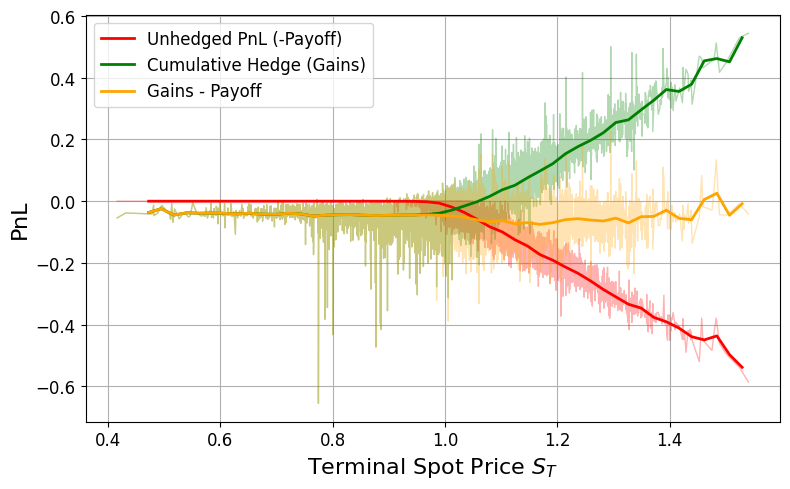

In [29]:
import matplotlib.pyplot as plt
from deephedging.proto_analysis_torch import binned_terminal_pnl

stoch_train_analysis = binned_terminal_pnl(world, r, n_bins=50, use_raw_pnl=True)

plt.figure(figsize=(8, 5))
plt.plot(stoch_train_analysis["sorted_spot_t"], stoch_train_analysis["sorted_payoff"], label="_nolegend_", color="red", alpha=0.3, linewidth=1)
plt.plot(stoch_train_analysis["sorted_spot_t"], stoch_train_analysis["sorted_gains"], label="_nolegend_", color="green", alpha=0.3, linewidth=1)
plt.plot(stoch_train_analysis["sorted_spot_t"], stoch_train_analysis["sorted_total"], label="_nolegend_", color="orange", alpha=0.3, linewidth=1)

plt.plot(stoch_train_analysis["bin_centers"], stoch_train_analysis["payoff_binned"], label="Unhedged PnL (-Payoff)", color="red", linewidth=2)
plt.plot(stoch_train_analysis["bin_centers"], stoch_train_analysis["gains_binned"], label="Cumulative Hedge (Gains)", color="green", linewidth=2)
plt.plot(stoch_train_analysis["bin_centers"], stoch_train_analysis["total_binned"], label="Gains - Payoff", color="orange", linewidth=2)

plt.xlabel("Terminal Spot Price $S_T$")
plt.ylabel("PnL")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


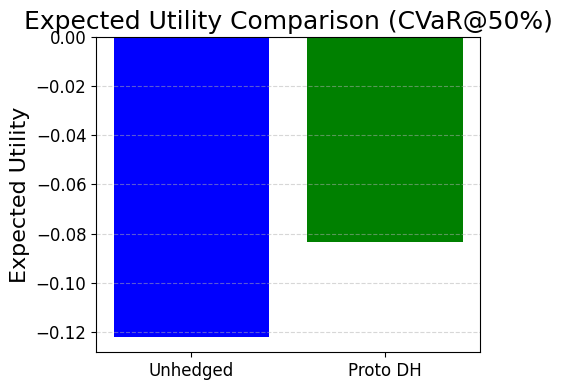

In [30]:
import numpy as np
import matplotlib.pyplot as plt

utility = r["utility"].numpy()
utility0 = r["utility0"].numpy()
weights = results_proto_stoch["sample_weights"]

mean_util = np.sum(weights * utility) / np.sum(weights)
mean_util0 = np.sum(weights * utility0) / np.sum(weights)

plt.figure(figsize=(5, 4))
plt.bar(["Unhedged", "Proto DH"], [mean_util0, mean_util], color=["blue", "green"])
plt.ylabel("Expected Utility")
plt.title("Expected Utility Comparison (CVaR@50%)")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Stochastic Volatility: Inference


In [31]:
import numpy as np
import random
import torch
from deephedging.proto_analysis_torch import ensure_stoch_test_context, load_prototype_payload

seed = 42
np.random.seed(seed)
torch.manual_seed(seed)
random.seed(seed)

agent = results_proto_stoch["model"]
payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=seed,
    samples=5000,
)


In [32]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
stoch_path_num = globals().get("stoch_path_num", -100)
globals()["stoch_path_num"] = stoch_path_num

stoch_test_result["utility0"][stoch_path_num], stoch_test_result["utility"][stoch_path_num]


(tensor(-0.5139), tensor(-0.0520))

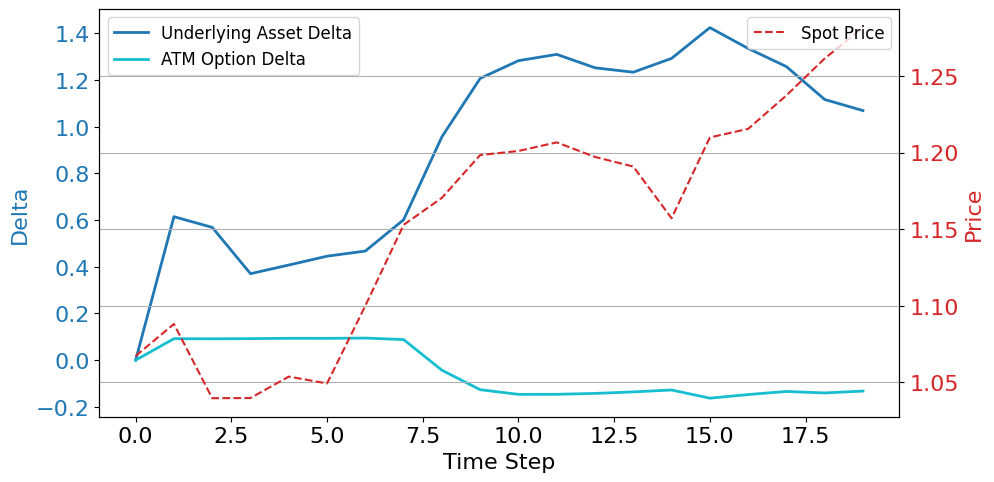

In [33]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt
import numpy as np
from deephedging.proto_analysis_torch import extract_stochastic_path_features

stoch_path_num = globals().get("stoch_path_num", -100)
path = extract_stochastic_path_features(stoch_test_world, stoch_test_result, stoch_path_num)
price = path["price"]
time_left = path["time_left"]
actions = path["actions"]
delta = path["delta"]

delta_1 = path["delta_1"]
delta_2 = path["delta_2"]
price_1 = path["price_1"]
price_2 = path["price_2"]
X = path["x"]

steps = np.arange(X.shape[0])

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Time Step', fontsize=16)
ax1.set_ylabel('Delta', color='tab:blue', fontsize=16)
ax1.plot(steps, delta_1, label='Underlying Asset Delta', color='tab:blue', linewidth=2)
ax1.plot(steps, delta_2, label='ATM Option Delta', color='tab:cyan', linewidth=2)
ax1.tick_params(axis='y', labelsize=16, labelcolor='tab:blue')
ax1.tick_params(axis='x', labelsize=16)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.set_ylabel('Price', color='tab:red', fontsize=16)
ax2.plot(steps, price_1, label='Spot Price', color='tab:red', linestyle='--')
ax2.tick_params(axis='y', labelcolor='tab:red', labelsize=16)
ax2.legend(loc='upper right')

plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
from deephedging.proto_analysis_torch import stochastic_similarity_details, load_prototype_payload
import numpy as np

stoch_path_num = globals().get("stoch_path_num", -100)
agent = results_proto_stoch["model"]
payload = load_prototype_payload(prototype_path_stoch)
scaler = payload['scaler']
prototypes = payload['prototypes']
proto_actions = agent.prototype_actions.detach().cpu().numpy()

stoch_path_details = stochastic_similarity_details(
    agent=agent,
    world=stoch_test_world,
    result=stoch_test_result,
    prototype_path=prototype_path_stoch,
    path_num=stoch_path_num,
    top_k=3,
)

feature_weights = stoch_path_details['feature_weights']
similarities = stoch_path_details['similarities']
X_scaled = stoch_path_details['x_scaled']
proto_layer = agent

globals()['agent'] = agent
globals()['stoch_path_details'] = stoch_path_details
globals()['feature_weights'] = feature_weights
globals()['similarities'] = similarities
globals()['X_scaled'] = X_scaled
globals()['proto_layer'] = proto_layer
globals()['prototypes'] = prototypes
globals()['scaler'] = scaler
globals()['proto_actions'] = proto_actions

for row in stoch_path_details['rows']:
    print()
    print(f"Step {row['step']}:")
    print(
        "  Input:        "
        f"delta=({row['input']['delta'][0]:.3f}, {row['input']['delta'][1]:.3f}), "
        f"price=({row['input']['price'][0]:.3f}, {row['input']['price'][1]:.3f}), "
        f"time_left={row['input']['time_left']:.3f}"
    )
    print(f"  Action:       ({row['action'][0]:.4f}, {row['action'][1]:.4f})")
    print("  Top 3 Prototypes:")
    for j, idx in enumerate(row['top_indices']):
        print(
            f"    - Prototype {int(idx)} | Features={np.round(row['top_prototypes'][j], 3)} "
            f"| Action={np.round(row['top_actions'][j], 3)} | Similarity={row['top_similarities'][j]:.3f}"
        )



Step 0:
  Input:        delta=(0.000, 0.000), price=(1.067, 0.024), time_left=0.400
  Action:       (0.6148, 0.0921)
  Top 3 Prototypes:
    - Prototype 247 | Features=[ 0.    -0.     1.054  0.027  0.4  ] | Action=[0.642 0.181] | Similarity=0.168
    - Prototype 25 | Features=[ 0.    -0.     1.048  0.022  0.4  ] | Action=[0.478 0.042] | Similarity=0.167
    - Prototype 436 | Features=[ 0.    -0.     1.089  0.024  0.4  ] | Action=[0.727 0.071] | Similarity=0.152

Step 1:
  Input:        delta=(0.615, 0.092), price=(1.088, 0.025), time_left=0.380
  Action:       (-0.0458, -0.0005)
  Top 3 Prototypes:
    - Prototype 442 | Features=[0.269 0.03  0.918 0.042 0.06 ] | Action=[-0.38   0.019] | Similarity=0.067
    - Prototype 466 | Features=[0.11  0.034 0.854 0.035 0.06 ] | Action=[-0.178 -0.008] | Similarity=0.053
    - Prototype 154 | Features=[0.066 0.058 0.879 0.037 0.06 ] | Action=[-0.144 -0.027] | Similarity=0.052

Step 2:
  Input:        delta=(0.569, 0.092), price=(1.040, 0.026), tim

In [35]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
proto_layer = results_proto_stoch["model"]
print([name for name, _ in proto_layer.named_parameters()])
print(proto_layer.feature_weights.detach().cpu().numpy())


['prototype_actions_unbounded', 'distance_feature_weights_unconstrained', 'pre_mlp.0.weight', 'pre_mlp.0.bias', 'pre_mlp.2.weight', 'pre_mlp.2.bias']
[1.2022452 0.9459801 1.2283566 0.9554091 1.1672194]


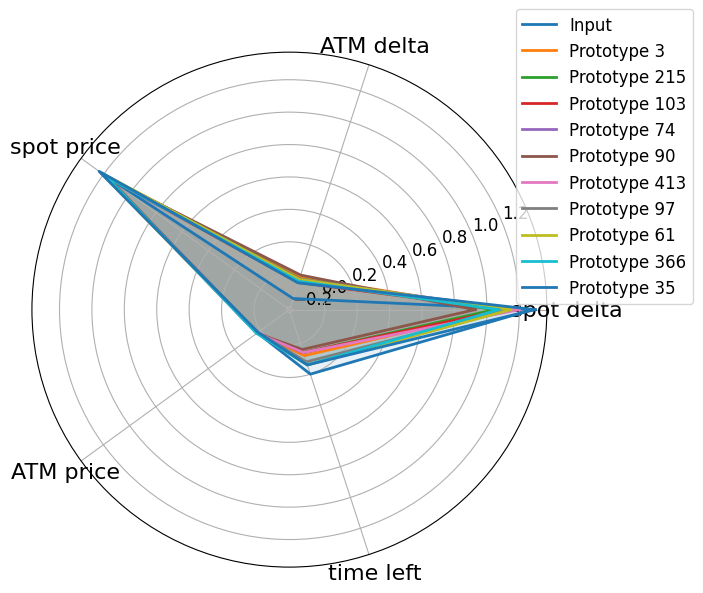

In [36]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt
import numpy as np
from deephedging.proto_analysis_torch import stochastic_similarity_details, load_prototype_payload

stoch_path_num = globals().get("stoch_path_num", -100)
stoch_path_details = globals().get("stoch_path_details")
if stoch_path_details is None:
    stoch_path_details = stochastic_similarity_details(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        path_num=stoch_path_num,
        top_k=3,
    )

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
X_scaled = stoch_path_details["x_scaled"]
similarities = stoch_path_details["similarities"]

t = 10
x_input_scaled = X_scaled[t]
x_input_raw = scaler.inverse_transform([x_input_scaled])[0]

top3_idx = np.argsort(-similarities[t])[:10]
prototypes_scaled = prototypes[top3_idx]
prototypes_raw = scaler.inverse_transform(prototypes_scaled)

vectors = [x_input_raw] + list(prototypes_raw)
labels = ["Input"] + [f"Prototype {idx}" for idx in top3_idx]

feature_names = ["spot delta", "ATM delta", "spot price", "ATM price", "time left"]
angles = np.linspace(0, 2 * np.pi, len(feature_names), endpoint=False).tolist()
angles += angles[:1]

vectors_closed = [np.append(v, v[0]) for v in vectors]

plt.figure(figsize=(7, 6))
ax = plt.subplot(111, polar=True)

for vec, label in zip(vectors_closed, labels):
    ax.plot(angles, vec, label=label, linewidth=2)
    ax.fill(angles, vec, alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feature_names, fontsize=16)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


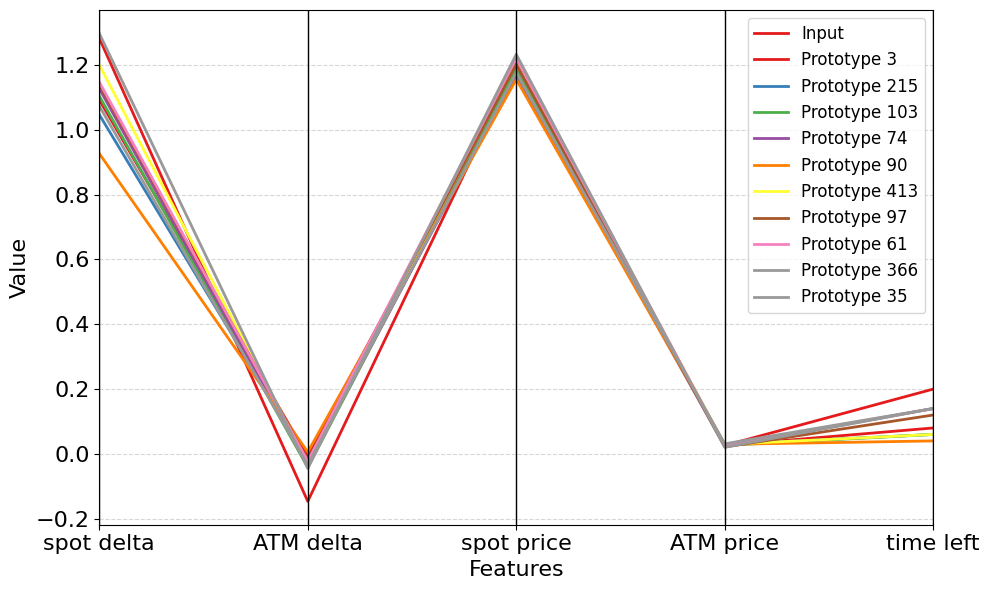

In [37]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from deephedging.proto_analysis_torch import stochastic_similarity_details, load_prototype_payload

stoch_path_num = globals().get("stoch_path_num", -100)
stoch_path_details = globals().get("stoch_path_details")
if stoch_path_details is None:
    stoch_path_details = stochastic_similarity_details(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        path_num=stoch_path_num,
        top_k=3,
    )

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
X_scaled = stoch_path_details["x_scaled"]
similarities = stoch_path_details["similarities"]

t = 10
top_n = 10
feature_names = ["spot delta", "ATM delta", "spot price", "ATM price", "time left"]

x_input_scaled = X_scaled[t]
x_input_raw = scaler.inverse_transform([x_input_scaled])[0]

topN_idx = np.argsort(-similarities[t])[:top_n]
protos_scaled = prototypes[topN_idx]
protos_raw = scaler.inverse_transform(protos_scaled)

rows = [x_input_raw] + list(protos_raw)
labels = ["Input"] + [f"Prototype {i}" for i in topN_idx]
df = pd.DataFrame(rows, columns=feature_names)
df["Type"] = labels

plt.figure(figsize=(10, 6))
pd.plotting.parallel_coordinates(df, class_column="Type", colormap=plt.cm.Set1, linewidth=2)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel("Features", fontsize=16)
plt.ylabel("Value", fontsize=16)

plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


In [38]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
print("Mean Utility (unhedged):", stoch_test_result["utility0"].numpy().mean())
print("Mean Utility (hedged):", stoch_test_result["utility"].numpy().mean())
print("pnl", stoch_test_result["pnl"].numpy().mean())


Mean Utility (unhedged): -0.12237942
Mean Utility (hedged): -0.09082542
pnl 0.0038377868


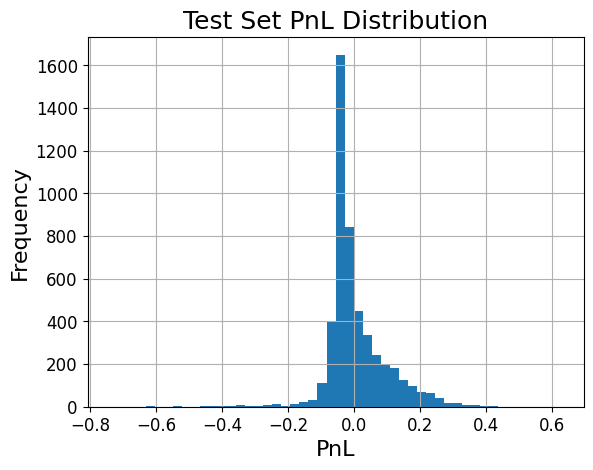

In [39]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt

plt.hist(stoch_test_result["pnl"].numpy(), bins=50)
plt.title("Test Set PnL Distribution")
plt.xlabel("PnL")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


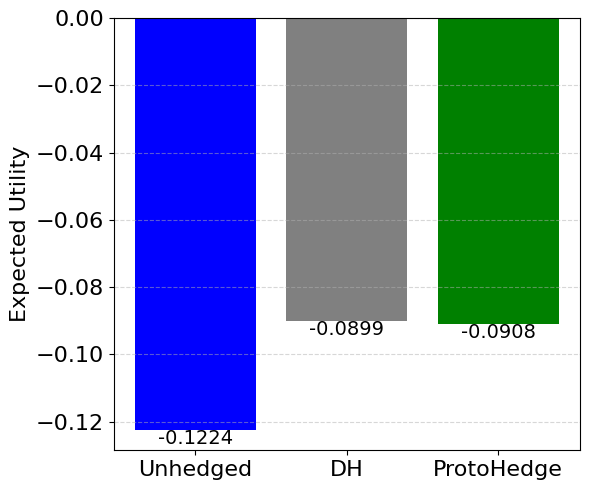

In [40]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt

unhedged_utility = stoch_test_result["utility0"].numpy().mean()
vanilla_dh_utility = stoch_test_result_vanilla["utility"].numpy().mean()
proto_dh_utility = stoch_test_result["utility"].numpy().mean()

labels = ['Unhedged', 'DH', 'ProtoHedge']
values = [unhedged_utility, vanilla_dh_utility, proto_dh_utility]
colors = ['blue', 'gray', 'green']

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=colors)

plt.ylabel("Expected Utility", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.grid(True, linestyle="--", alpha=0.5, axis='y')

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, val - 0.0055, f"{val:.4f}",
             ha='center', va='bottom', fontsize=14)

plt.tight_layout()
plt.show()


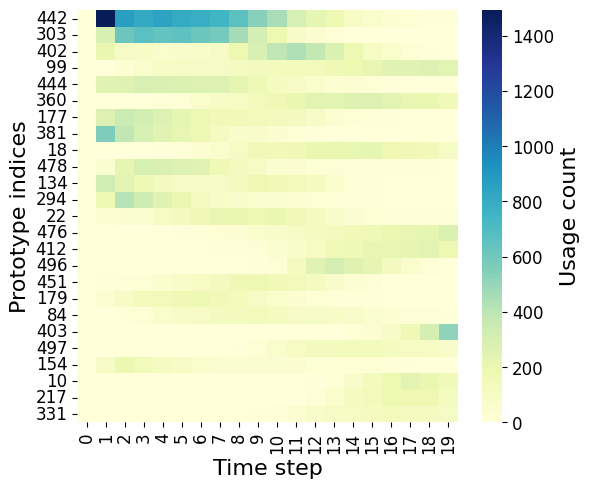

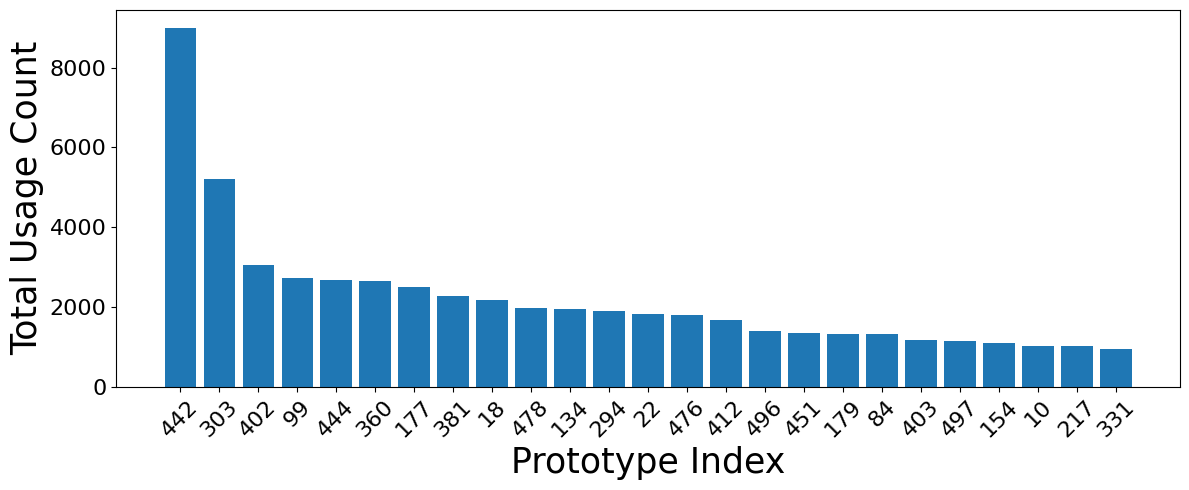

In [41]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt
import seaborn as sns
from deephedging.proto_analysis_torch import stochastic_prototype_usage

stoch_usage = stochastic_prototype_usage(
    agent=results_proto_stoch["model"],
    world=stoch_test_world,
    result=stoch_test_result,
    prototype_path=prototype_path_stoch,
    top_n=25,
)

globals()["stoch_usage"] = stoch_usage
heatmap = stoch_usage['heatmap']
totals = stoch_usage['totals']
top_indices = stoch_usage['top_indices']
filtered_heatmap = stoch_usage['top_heatmap']

plt.figure(figsize=(6, 5))
sns.heatmap(filtered_heatmap, cmap="YlGnBu", cbar_kws={'label': 'Usage count'}, yticklabels=top_indices)
plt.xlabel("Time step")
plt.ylabel("Prototype indices")
plt.tight_layout()
plt.show()

top_25_vals = totals[top_indices]

plt.figure(figsize=(12, 5))
plt.bar(range(25), top_25_vals, tick_label=top_indices)
plt.xlabel("Prototype Index", fontsize=25)
plt.ylabel("Total Usage Count", fontsize=25)
plt.xticks(rotation=45, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()


In [42]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import pandas as pd
from IPython.display import display
from deephedging.proto_analysis_torch import stochastic_prototype_usage, load_prototype_payload

stoch_usage = globals().get("stoch_usage")
if stoch_usage is None:
    stoch_usage = stochastic_prototype_usage(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        top_n=25,
    )
    globals()["stoch_usage"] = stoch_usage

top_indices = stoch_usage['top_indices']
payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes_np = payload["prototypes"]
proto_actions_np = results_proto_stoch["model"].prototype_actions.detach().cpu().numpy()

top_10_idx = np.array(top_indices[:10], dtype=int)
top_10_prototypes = prototypes_np[top_10_idx]
top_10_actions = proto_actions_np[top_10_idx]
original_features = scaler.inverse_transform(top_10_prototypes)

df = pd.DataFrame(original_features, columns=["delta_1", "delta_2", "price_1", "price_2", "time_left"])
df["action_1"] = top_10_actions[:, 0]
df["action_2"] = top_10_actions[:, 1]
df["prototype_index"] = top_10_idx

df = df[["prototype_index", "delta_1", "delta_2", "price_1", "price_2", "time_left", "action_1", "action_2"]]

display(df)


,prototype_index,delta_1,delta_2,price_1,price_2,time_left,action_1,action_2
0,442,0.268574,0.030395,0.918366,0.041707,0.06,-0.380257,0.019180
1,303,0.294648,0.032484,0.928782,0.026664,0.14,-0.044889,-0.027075
2,402,0.302093,0.040915,0.935124,0.027821,0.06,-0.191345,-0.005415
3,99,-0.020992,0.075737,0.825857,0.019309,0.04,-0.173683,0.043112
4,444,0.230469,0.050551,0.936409,0.033445,0.06,-0.033887,0.008979
5,360,-0.030287,0.052201,0.793595,0.043022,0.06,-0.118949,-0.000881
6,177,0.258335,0.034514,0.911797,0.021576,0.12,-0.025445,0.006297
7,381,0.257346,0.029235,0.913733,0.016738,0.22,0.007933,0.006618
8,18,0.123919,0.051284,0.901972,0.020939,0.12,0.034605,0.010459
9,478,0.114361,0.028905,0.897021,0.031174,0.18,0.099260,-0.037720


In [43]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
from deephedging.proto_analysis_torch import stochastic_prototype_usage

stoch_usage = globals().get("stoch_usage")
if stoch_usage is None:
    stoch_usage = stochastic_prototype_usage(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        top_n=25,
    )
    globals()["stoch_usage"] = stoch_usage

totals = stoch_usage['totals']
num_used_prototypes = np.sum(totals > 0)
print(f"Number of used prototypes: {num_used_prototypes}")


Number of used prototypes: 399


In [44]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
results_proto_stoch["model"].print_sample_prototypes([737])


Prototype 737: out of range for 500 stored prototypes


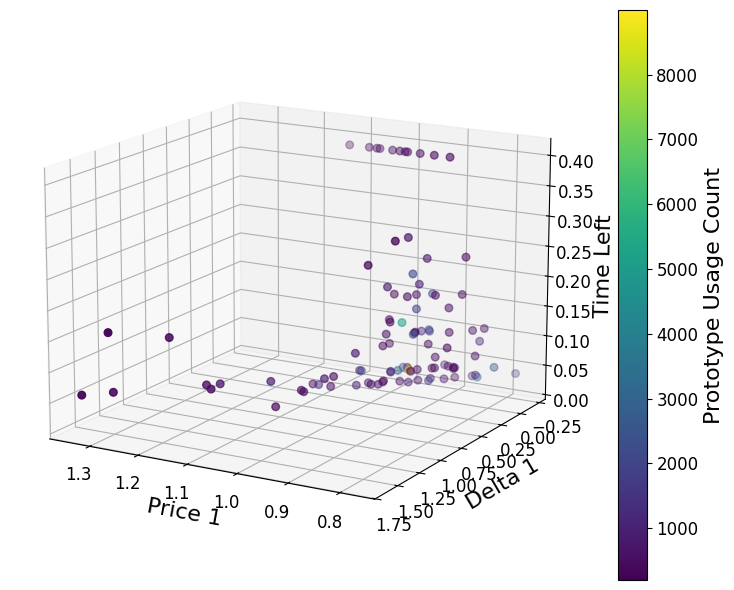

In [45]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import matplotlib.pyplot as plt
from deephedging.proto_analysis_torch import stochastic_prototype_usage, load_prototype_payload

stoch_usage = globals().get("stoch_usage")
if stoch_usage is None:
    stoch_usage = stochastic_prototype_usage(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        top_n=25,
    )
    globals()["stoch_usage"] = stoch_usage

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
features_raw = scaler.inverse_transform(prototypes)
price_1 = features_raw[:, 2]
delta_1 = features_raw[:, 0]
time_left = features_raw[:, 4]
usage_counts = np.sum(stoch_usage['heatmap'], axis=1)

top_25_indices = np.argsort(usage_counts)[-100:]
price_1_top = price_1[top_25_indices]
delta_1_top = delta_1[top_25_indices]
time_left_top = time_left[top_25_indices]
usage_top = usage_counts[top_25_indices]

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1_top, delta_1_top, time_left_top, c=usage_top, cmap='viridis', s=30)

ax.view_init(elev=15, azim=120)
ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
fig.colorbar(p, ax=ax, label="Prototype Usage Count")

plt.tight_layout()
plt.show()


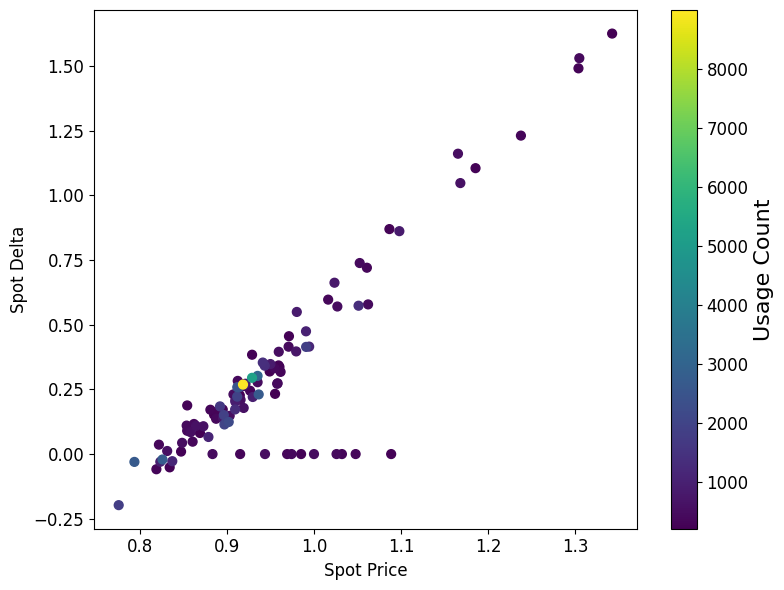

In [46]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import matplotlib.pyplot as plt
from deephedging.proto_analysis_torch import stochastic_prototype_usage, load_prototype_payload

stoch_usage = globals().get("stoch_usage")
if stoch_usage is None:
    stoch_usage = stochastic_prototype_usage(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        top_n=25,
    )
    globals()["stoch_usage"] = stoch_usage

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
features_raw = scaler.inverse_transform(prototypes)
price_1 = features_raw[:, 2]
delta_1 = features_raw[:, 0]
usage_counts = np.sum(stoch_usage['heatmap'], axis=1)

top_25_indices = np.argsort(usage_counts)[-100:]
price_1_top = price_1[top_25_indices]
delta_1_top = delta_1[top_25_indices]
usage_top = usage_counts[top_25_indices]

plt.figure(figsize=(8, 6))
sc = plt.scatter(price_1_top, delta_1_top, c=usage_top, cmap='viridis', s=40)

plt.xlabel("Spot Price", fontsize=12)
plt.ylabel("Spot Delta", fontsize=12)
plt.colorbar(sc, label="Usage Count")
plt.tight_layout()
plt.show()


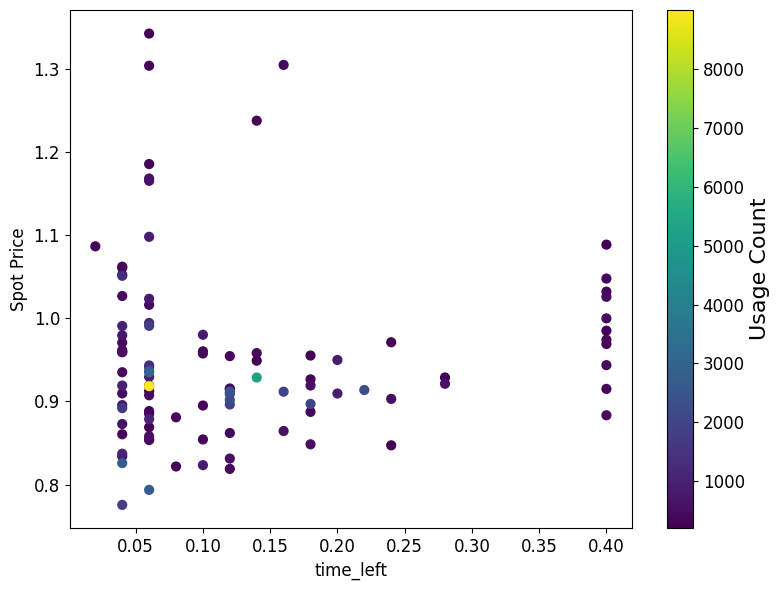

In [47]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import matplotlib.pyplot as plt
from deephedging.proto_analysis_torch import stochastic_prototype_usage, load_prototype_payload

stoch_usage = globals().get("stoch_usage")
if stoch_usage is None:
    stoch_usage = stochastic_prototype_usage(
        agent=results_proto_stoch["model"],
        world=stoch_test_world,
        result=stoch_test_result,
        prototype_path=prototype_path_stoch,
        top_n=25,
    )
    globals()["stoch_usage"] = stoch_usage

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
features_raw = scaler.inverse_transform(prototypes)
time = features_raw[:, 4]
price_1 = features_raw[:, 2]
usage_counts = np.sum(stoch_usage['heatmap'], axis=1)

top_25_indices = np.argsort(usage_counts)[-100:]
price_1_top = price_1[top_25_indices]
time_top = time[top_25_indices]
usage_top = usage_counts[top_25_indices]

plt.figure(figsize=(8, 6))
sc = plt.scatter(time_top, price_1_top, c=usage_top, cmap='viridis', s=40)

plt.xlabel("time_left", fontsize=12)
plt.ylabel("Spot Price", fontsize=12)
plt.colorbar(sc, label="Usage Count")
plt.tight_layout()
plt.show()


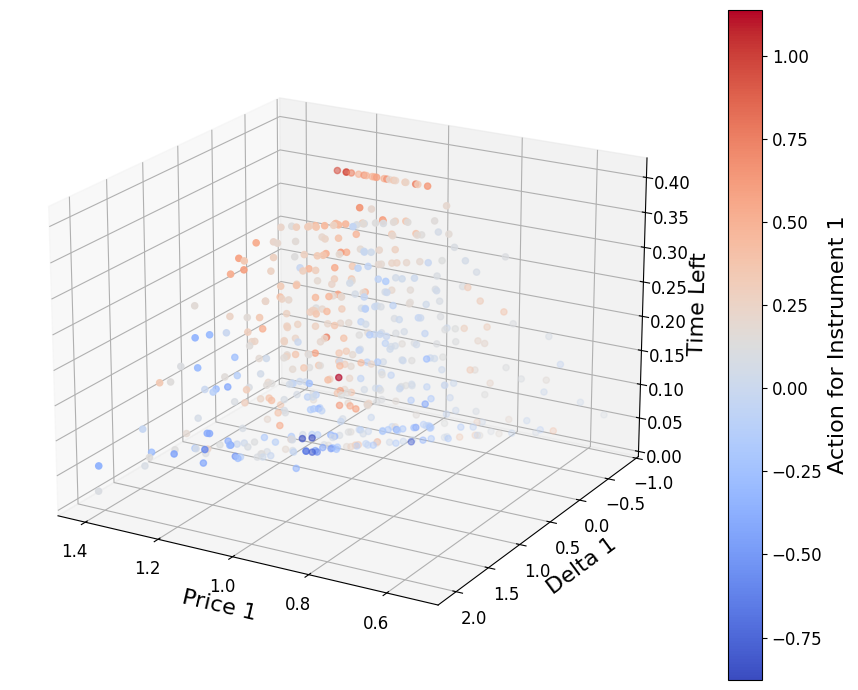

In [48]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from deephedging.proto_analysis_torch import load_prototype_payload

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_stoch["model"].prototype_actions.detach().cpu().numpy()

prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 2]
delta_1 = prototypes_raw[:, 0]
time_left = prototypes_raw[:, 4]
action_1 = proto_actions[:, 0]

globals()["price_1"] = price_1
globals()["delta_1"] = delta_1
globals()["time_left"] = time_left
globals()["action_1"] = action_1

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', s=20)

ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
fig.colorbar(p, ax=ax, label="Action for Instrument 1")
ax.view_init(elev=20, azim=120)

plt.tight_layout()
plt.show()


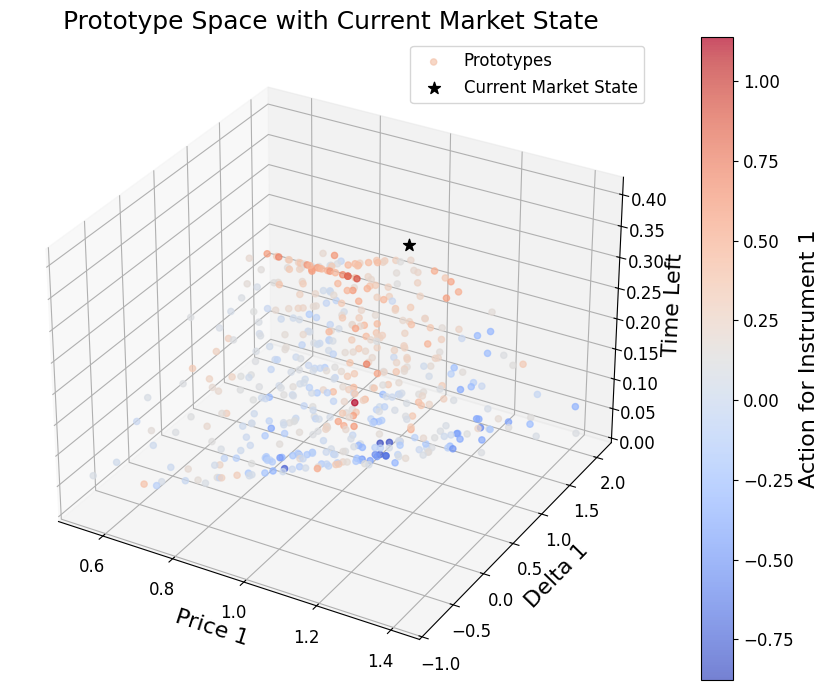

In [49]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from deephedging.proto_analysis_torch import load_prototype_payload

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_stoch["model"].prototype_actions.detach().cpu().numpy()

prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 2]
delta_1 = prototypes_raw[:, 0]
time_left = prototypes_raw[:, 4]
action_1 = proto_actions[:, 0]

t = 1
price = stoch_test_world.data.features.per_step['price'][-1][t]
delta = np.cumsum(stoch_test_result['actions'][-1].numpy(), axis=0) - stoch_test_result['actions'][-1].numpy()
delta = delta[t]
time = stoch_test_world.data.features.per_step['time_left'][-1][t]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', s=20, alpha=0.7, label='Prototypes')
ax.scatter(price[0], delta[0], time, c='black', s=80, marker='*', label='Current Market State')

ax.set_xlabel("Price 1")
ax.set_ylabel("Delta 1")
ax.set_zlabel("Time Left")
ax.set_title("Prototype Space with Current Market State")
fig.colorbar(p, ax=ax, label="Action for Instrument 1")
ax.legend()

plt.tight_layout()
plt.show()


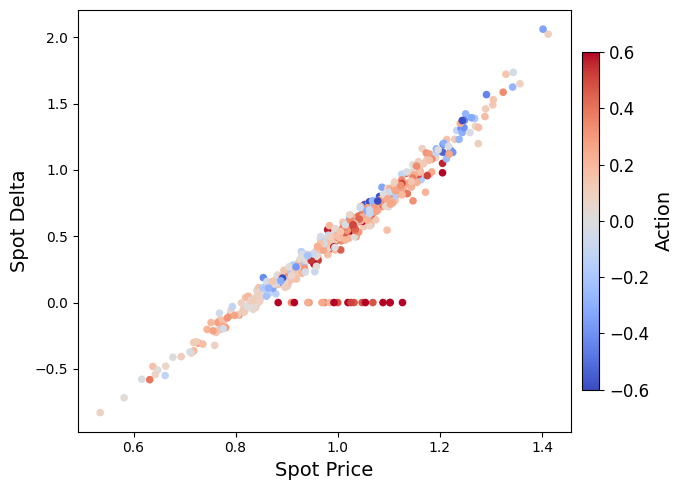

In [50]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from deephedging.proto_analysis_torch import load_prototype_payload

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_stoch["model"].prototype_actions.detach().cpu().numpy()
prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 2]
delta_1 = prototypes_raw[:, 0]
action_1 = proto_actions[:, 0]

abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

plt.figure(figsize=(7, 5))
sc = plt.scatter(price_1, delta_1, c=action_1, cmap='coolwarm', norm=norm, s=20)

plt.xlabel("Spot Price", fontsize=14)
plt.ylabel("Spot Delta", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

cbar = plt.colorbar(sc, shrink=0.8, pad=0.02)
cbar.set_label("Action", fontsize=14)

plt.tight_layout()
plt.show()


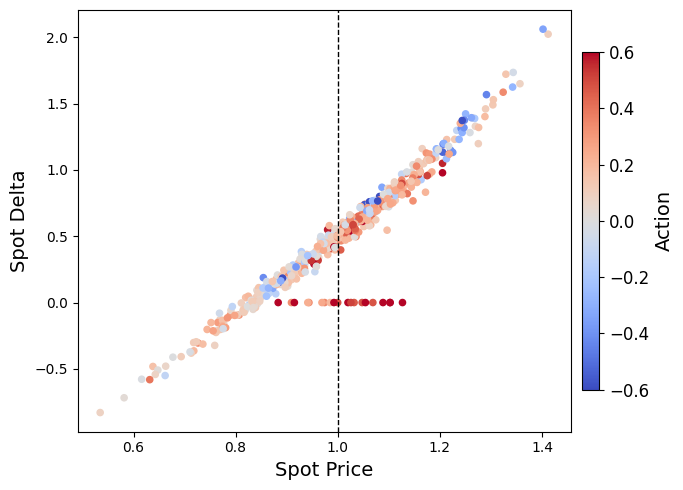

In [51]:
from deephedging.proto_analysis_torch import ensure_stoch_test_context

stoch_test_world, stoch_test_data, stoch_test_result, stoch_test_result_vanilla, results_stoch_vanilla = ensure_stoch_test_context(
    results_proto_stoch=results_proto_stoch,
    results_stoch_vanilla=globals().get("results_stoch_vanilla"),
    seed=42,
    samples=5000,
)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from deephedging.proto_analysis_torch import load_prototype_payload

payload = load_prototype_payload(prototype_path_stoch)
scaler = payload["scaler"]
prototypes = payload["prototypes"]
proto_actions = results_proto_stoch["model"].prototype_actions.detach().cpu().numpy()
prototypes_raw = scaler.inverse_transform(prototypes)
price_1 = prototypes_raw[:, 2]
delta_1 = prototypes_raw[:, 0]
action_1 = proto_actions[:, 0]

abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

plt.figure(figsize=(7, 5))
sc = plt.scatter(price_1, delta_1, c=action_1, cmap='coolwarm', norm=norm, s=20)
plt.axvline(x=1.0, color='black', linestyle='--', linewidth=1)

plt.xlabel("Spot Price", fontsize=14)
plt.ylabel("Spot Delta", fontsize=14)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

cbar = plt.colorbar(sc, shrink=0.8, pad=0.02)
cbar.set_label("Action", fontsize=14)

plt.tight_layout()
plt.show()


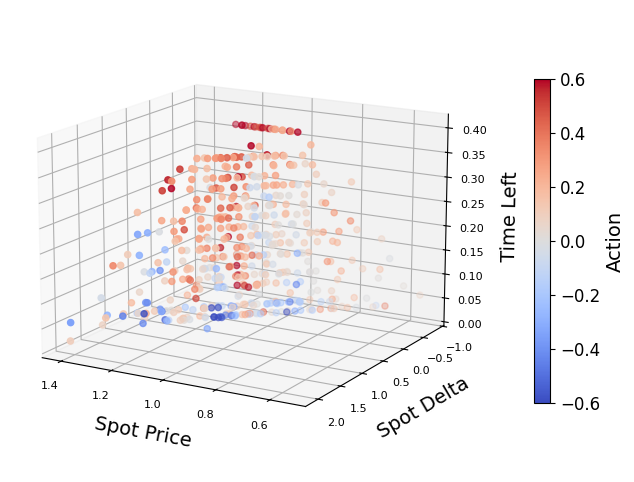

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

# Set symmetric color scale
abs_max = np.max(np.abs(action_1))
symmetric_limit = np.ceil(abs_max * 5) / 10
norm = TwoSlopeNorm(vmin=-symmetric_limit, vcenter=0.0, vmax=symmetric_limit)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(price_1, delta_1, time_left, c=action_1, cmap='coolwarm', norm=norm, s=20)

# Adjust font sizes and spacing
ax.view_init(elev=15, azim=120)
ax.set_xlabel("Spot Price", fontsize=14, labelpad=8)
ax.set_ylabel("Spot Delta", fontsize=14, labelpad=8)
ax.set_zlabel("Time Left", fontsize=14, labelpad=8)


ax.tick_params(axis='both', which='major', labelsize=8)

# Add colorbar
cbar = fig.colorbar(p, ax=ax, shrink=0.7, pad=0.1)
cbar.set_label("Action", fontsize=14)

plt.show()